<a href="https://colab.research.google.com/github/elsms/BTC-Blockspace-Economics/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
d = pd.read_csv('BlockData_2020_2025.csv')
d.head()

,id,hash,time,block_time_secs,median_time,size,stripped_size,weight,version,version_hex,...,fee_per_kb_usd,fee_per_kwu,fee_per_kwu_usd,cdd_total,generation,generation_usd,reward,reward_usd,guessed_miner,bitcoin_price_usd
0,610691,00000000000000000001cc49c6ebb2e7546615e1f16816...,01/01/2020 00:03,NaN,31/12/2019 23:07,1250129,914500,3993629,549453824,20c00000,...,1.0096,4392.34,0.3160,17164.324800,1250000000,89939.375,1267534026,91200.9766,Unknown,7130.40
1,610692,000000000000000000117f1821db8f36e05a70ed9dbffa...,01/01/2020 00:07,267.0,31/12/2019 23:13,661706,424345,1934741,536870912,20000000,...,0.6010,2857.26,0.2056,2792.642387,1250000000,89939.375,1255524017,90336.8359,Unknown,7130.42
2,610693,00000000000000000014a2d6530192263dffbb1723acc9...,01/01/2020 00:13,362.0,31/12/2019 23:22,436344,284543,1289973,1073733632,3fffe000,...,0.7130,3352.70,0.2413,6755.644735,1250000000,89939.375,1254319091,90250.1406,F2Pool,7133.45
3,610694,000000000000000000053ba498a77d2e186a0d530abe5c...,01/01/2020 00:19,326.0,31/12/2019 23:37,467181,285676,1324209,1073733632,3fffe000,...,0.4280,2099.23,0.1510,564.570718,1250000000,89939.375,1252776912,90139.1797,Unknown,7142.20
4,610695,00000000000000000009ae968a937bea55223270e64058...,01/01/2020 00:37,1112.0,31/12/2019 23:41,1123752,758667,3399753,545259520,20800000,...,0.5617,2580.31,0.1856,35967.771680,1250000000,89939.375,1258768740,90570.2969,AntPool,7148.87


In [ ]:
d.tail()

,id,hash,time,block_time_secs,median_time,size,stripped_size,weight,version,version_hex,...,fee_per_kb_usd,fee_per_kwu,fee_per_kwu_usd,cdd_total,generation,generation_usd,reward,reward_usd,guessed_miner,bitcoin_price_usd
319643,930336,00000000000000000000e366a575096d7efcf070427314...,31/12/2025 23:40,1062.0,31/12/2025 22:26,1599602,780810,3942032,538583040,201a2000,...,1.5416,709.06660,0.6256,433020.144700,312500000,275756.25,315293487,278221.2812,F2Pool,87526.12
319644,930337,00000000000000000001d6b1d2ff246faa85319eab42ce...,31/12/2025 23:41,53.0,31/12/2025 22:38,43202,22493,110681,974151680,3a106000,...,1.4604,649.94800,0.5736,135.998253,312500000,275756.25,312570624,275818.5625,ViaBTC,87526.00
319645,930338,00000000000000000000ff55a59911d5dafbbd0e074689...,31/12/2025 23:52,643.0,31/12/2025 23:15,1759593,744536,3993201,537206784,20052000,...,0.9733,486.17358,0.4289,506729.331900,312500000,275756.25,314440714,277468.7812,SpiderPool,87527.55
319646,930339,000000000000000000008345aae74a1655ecd7e65982e9...,31/12/2025 23:57,273.0,31/12/2025 23:16,1733554,753373,3993673,872415232,34000000,...,0.4033,198.51400,0.1756,1063.629504,312500000,275756.25,313292376,276455.4688,Unknown,87492.60
319647,930340,00000000000000000001df056a7ffb042578785c6b44b3...,31/12/2025 23:59,170.0,31/12/2025 23:23,1734800,752969,3993707,537976832,2.01E+03,...,0.3371,165.93808,0.1465,3145.663341,312500000,275756.25,313162420,276340.7812,Foundry USA Pool,87496.00


In [ ]:
d.shape

(319648, 38)

In [ ]:
d.dtypes

In [ ]:
d.columns

Index(['id', 'hash', 'time', 'block_time_secs', 'median_time', 'size',
       'stripped_size', 'weight', 'version', 'version_hex', 'version_bits',
       'merkle_root', 'nonce', 'bits', 'difficulty', 'chainwork',
       'coinbase_data_hex', 'transaction_count', 'witness_count',
       'input_count', 'output_count', 'input_total', 'input_total_usd',
       'output_total', 'output_total_usd', 'fee_total', 'fee_total_usd',
       'fee_per_kb', 'fee_per_kb_usd', 'fee_per_kwu', 'fee_per_kwu_usd',
       'cdd_total', 'generation', 'generation_usd', 'reward', 'reward_usd',
       'guessed_miner', 'bitcoin_price_usd'],
      dtype='object')

In [3]:
d['time'] = pd.to_datetime(d['time'].str.strip(), dayfirst=True) # Pandas expects MM/DD/YYYY by default
d['median_time'] = pd.to_datetime(d['median_time'].str.strip(), dayfirst=True)

In [5]:
print(d['time'].dtype)
print(d['median_time'].dtype)

datetime64[ns]
datetime64[ns]


# Question 3

**Q3 - Did COVID-era market stress materially increase transaction urgency on the Bitcoin network?**

During March–April 2020, global financial markets experienced extreme volatility and liquidity stress. Using the dataset, compare transaction fees per transaction, transaction counts per block, and block utilisation during the COVID stress period with a calmer baseline period later in 2020. Analyse how volatility in fees and transaction activity changed across these periods and whether any increases were persistent or short-lived. Quantify whether users paid measurable urgency premiums to prioritise settlement during market stress. Use external sources to contextualise crypto market behaviour during the COVID liquidity shock and to validate whether observed on-chain behaviour aligns with broader market narratives.

## Variables Comparison

In [ ]:
'''
Variables to use:
- fee per transaction
- transaction counts per block (transaction count)
- block utilization
'''

In [ ]:
print(d['size'].describe()) # segWit is in use > without it, size would be maxed out at 1MB
print(d['weight'].describe()) # better to use weight to compute block utilization

count    3.196480e+05
mean     1.420703e+06
std      4.750069e+05
min      1.990000e+02
25%      1.267993e+06
50%      1.489475e+06
75%      1.655048e+06
max      3.993936e+06
Name: size, dtype: float64
count    3.196480e+05
mean     3.632335e+06
std      9.513466e+05
min      7.960000e+02
25%      3.992916e+06
50%      3.993296e+06
75%      3.993628e+06
max      3.999855e+06
Name: weight, dtype: float64


In [ ]:
start = pd.to_datetime('01-03-2020', dayfirst=True)
end = pd.to_datetime('01-05-2020', dayfirst=True)
march_april = d[(d['time'] >= start) & (d['time'] <= end)]
march_april['fee_per_transaction'] = np.log1p(march_april['fee_total']/march_april['transaction_count']) #log(0) is undefined
march_april['transaction_count'] = np.log1p(march_april['transaction_count'])
march_april['block_utilization'] = (march_april['weight']/4000000)*100

In [ ]:
start = pd.to_datetime('01-12-2020', dayfirst=True)
end = pd.to_datetime('01-01-2021', dayfirst=True)
baseline = d[(d['time'] >= start) & (d['time'] <= end)]
baseline['fee_per_transaction'] = np.log1p(baseline['fee_total']/baseline['transaction_count']) #log(0) is undefined
baseline['transaction_count'] = np.log1p(baseline['transaction_count'])
baseline['block_utilization'] = (baseline['weight']/4000000)*100

In [7]:
print(march_april['time'].max())
print(baseline['time'].max())

2020-04-30 23:51:00
2020-12-31 23:57:00


In [8]:
print(march_april['fee_per_transaction'].describe())
print(march_april['transaction_count'].describe())
print(march_april['block_utilization'].describe())

count    8768.000000
mean        9.029171
std         0.907779
min         0.000000
25%         8.584180
50%         8.991094
75%         9.482761
max        13.159558
Name: fee_per_transaction, dtype: float64
count    8768.000000
mean        7.397048
std         0.871705
min         0.693147
25%         7.240650
50%         7.721349
75%         7.904704
max         8.251403
Name: transaction_count, dtype: float64
count    8768.000000
mean       84.715137
std        28.937020
min         0.024400
25%        88.725763
50%        99.830800
75%        99.836025
max        99.969175
Name: block_utilization, dtype: float64


In [9]:
print(baseline['fee_per_transaction'].describe())
print(baseline['transaction_count'].describe())
print(baseline['block_utilization'].describe())

count    4514.000000
mean       10.109099
std         1.029464
min         0.000000
25%         9.727337
50%        10.243373
75%        10.649092
max        12.900061
Name: fee_per_transaction, dtype: float64
count    4514.000000
mean        7.573546
std         0.680511
min         0.693147
25%         7.480428
50%         7.722456
75%         7.886081
max         8.205218
Name: transaction_count, dtype: float64
count    4514.000000
mean       98.118816
std        11.582064
min         0.022800
25%        99.829500
50%        99.835900
75%        99.963425
max        99.991575
Name: block_utilization, dtype: float64


### Outliers: March - April (2020)

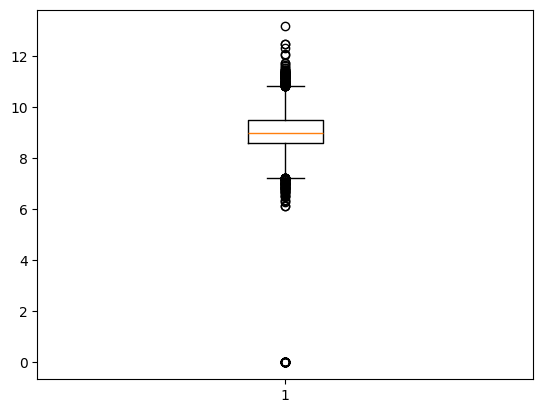

In [10]:
plt.boxplot(march_april['fee_per_transaction']) # if = 0 > unusual since miners prioritize transactions that pay more
# > a transaction that pays 0 will probably be ignored and eventually dropped
plt.show()

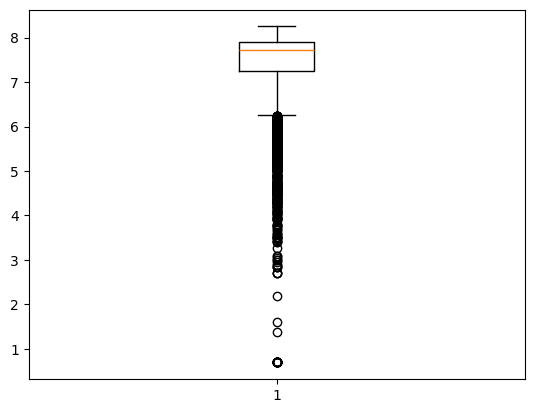

In [11]:
plt.boxplot(march_april['transaction_count'])
plt.show()

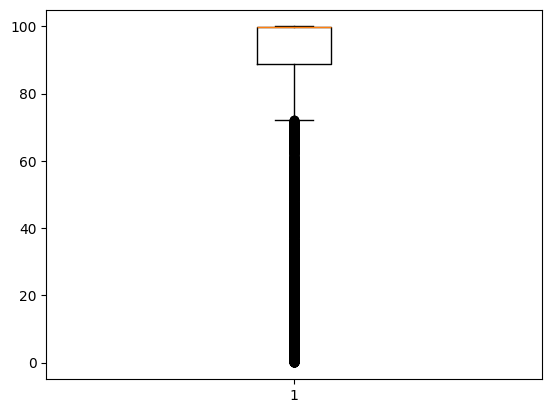

In [12]:
plt.boxplot(march_april['block_utilization']) # anomalies
plt.show()

In [13]:
march_april = march_april[(march_april['fee_per_transaction'] > 0) & (march_april['transaction_count'] > 0)
& (march_april['block_utilization'] > 0)]
print(march_april['fee_per_transaction'].describe().round(4))
print(march_april['transaction_count'].describe().round(4))
print(march_april['block_utilization'].describe().round(4))

count    8739.0000
mean        9.0591
std         0.7452
min         6.1187
25%         8.5876
50%         8.9941
75%         9.4844
max        13.1596
Name: fee_per_transaction, dtype: float64
count    8739.0000
mean        7.4192
std         0.7834
min         1.6094
25%         7.2506
50%         7.7227
75%         7.9051
max         8.2514
Name: transaction_count, dtype: float64
count    8739.0000
mean       84.9961
std        28.5701
min         0.1162
25%        90.0699
50%        99.8308
75%        99.8360
max        99.9692
Name: block_utilization, dtype: float64


### Outliers: December 2020

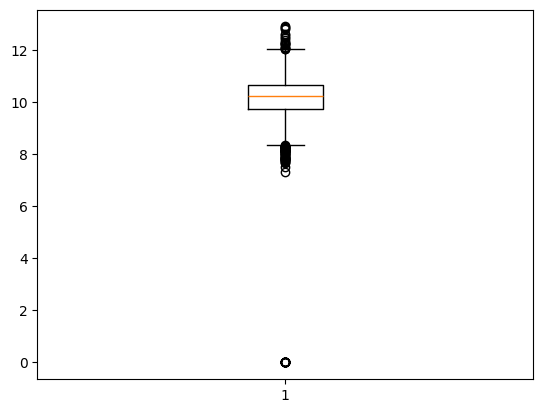

In [14]:
plt.boxplot(baseline['fee_per_transaction']) # outlier
plt.show()

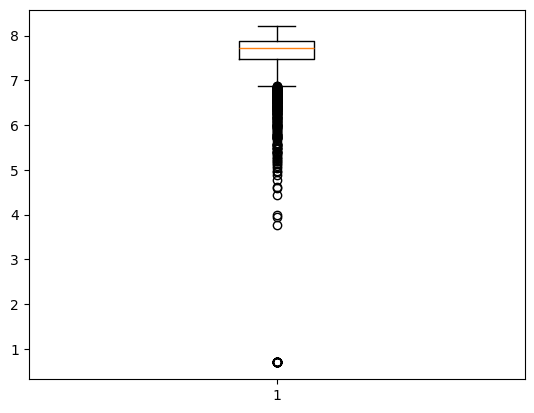

In [15]:
plt.boxplot(baseline['transaction_count']) # outlier
plt.show()

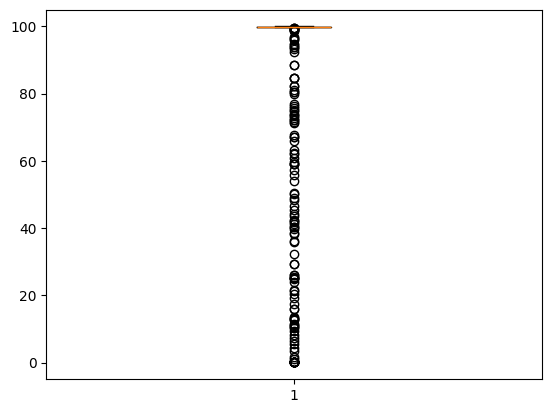

In [16]:
plt.boxplot(baseline['block_utilization']) # anomalies
plt.show()

In [17]:
baseline = baseline[(baseline['fee_per_transaction'] > 0) & (baseline['transaction_count'] > 0) & (baseline['block_utilization'] > 0)]
print(baseline['fee_per_transaction'].describe().round(4))
print(baseline['transaction_count'].describe().round(4))
print(baseline['block_utilization'].describe().round(4))

count    4488.0000
mean       10.1677
std         0.6858
min         7.3311
25%         9.7405
50%        10.2467
75%        10.6503
max        12.9001
Name: fee_per_transaction, dtype: float64
count    4488.0000
mean        7.6134
std         0.4357
min         3.7612
25%         7.4870
50%         7.7247
75%         7.8866
max         8.2052
Name: transaction_count, dtype: float64
count    4488.0000
mean       98.6871
std         8.8796
min         0.9968
25%        99.8296
50%        99.8360
75%        99.9635
max        99.9916
Name: block_utilization, dtype: float64


### Data Visualization

#### Transaction Fees

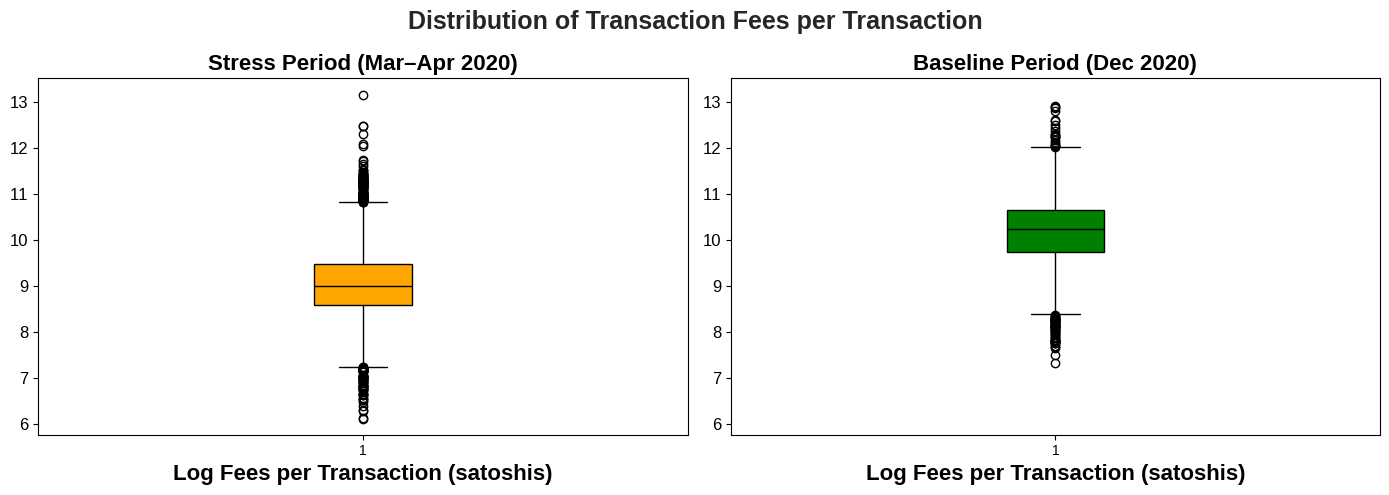

In [18]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,5), sharey=True)

plt.style.use('seaborn-v0_8-whitegrid')

fig.suptitle(
    'Distribution of Transaction Fees per Transaction',
    fontsize=18,
    fontweight='bold'
)

axes[0].boxplot(march_april['fee_per_transaction'], patch_artist=True,
            boxprops=dict(facecolor='orange'), medianprops=dict(color='black'))
axes[0].set_title('Stress Period (Mar–Apr 2020)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Log Fees per Transaction (satoshis)', fontsize=16, fontweight='bold')
axes[0].tick_params('y', labelsize=12)

axes[1].boxplot(baseline['fee_per_transaction'], patch_artist=True,
            boxprops=dict(facecolor='green'), medianprops=dict(color='black'))
axes[1].set_title('Baseline Period (Dec 2020)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Log Fees per Transaction (satoshis)', fontsize=16, fontweight='bold')
axes[1].tick_params('y', labelsize=12)
axes[1].tick_params(labelleft=True)

plt.tight_layout()
plt.show()

In [ ]:
# 2020 subset
start = d['time'].min()
end = pd.to_datetime('01-01-2021', dayfirst=True)
data = d[(d['time'] >= start) & (d['time'] < end)]

data['fee_per_transaction'] = np.log1p(data['fee_total']/data['transaction_count']) #log(0) is undefined
data['transaction_count'] = np.log1p(data['transaction_count'])
data['block_utilization'] = (data['weight']/4000000)*100

data = data.set_index('time', drop=True)
data.drop(columns=data.select_dtypes(include='object').columns, inplace=True)
data = data.resample('D').median()

# Stress period subset
start = pd.to_datetime('01-03-2020', dayfirst=True)
end = pd.to_datetime('01-05-2020', dayfirst=True)
stress = d[(d['time'] >= start) & (d['time'] < end)]

stress['fee_per_transaction'] = np.log1p(stress['fee_total']/stress['transaction_count']) #log(0) is undefined
stress['transaction_count'] = np.log1p(stress['transaction_count'])
stress['block_utilization'] = (stress['weight']/4000000)*100

stress = stress.set_index('time', drop=True)
stress.drop(columns=stress.select_dtypes(include='object').columns, inplace=True)
stress = stress.resample('D').median()

# Baseline period subset
start = pd.to_datetime('01-12-2020', dayfirst=True)
end = pd.to_datetime('01-01-2021', dayfirst=True)
base = d[(d['time'] >= start) & (d['time'] < end)]

base['fee_per_transaction'] = np.log1p(base['fee_total']/base['transaction_count']) #log(0) is undefined
base['transaction_count'] = np.log1p(base['transaction_count'])
base['block_utilization'] = (base['weight']/4000000)*100

base = base.set_index('time', drop=True)
base.drop(columns=base.select_dtypes(include='object').columns, inplace=True)
base = base.resample('D').median()

In [20]:
print(stress.index.max())
print(stress.index.min())

print(base.index.max())
print(base.index.min())

2020-04-30 00:00:00
2020-03-01 00:00:00
2020-12-31 00:00:00
2020-12-01 00:00:00


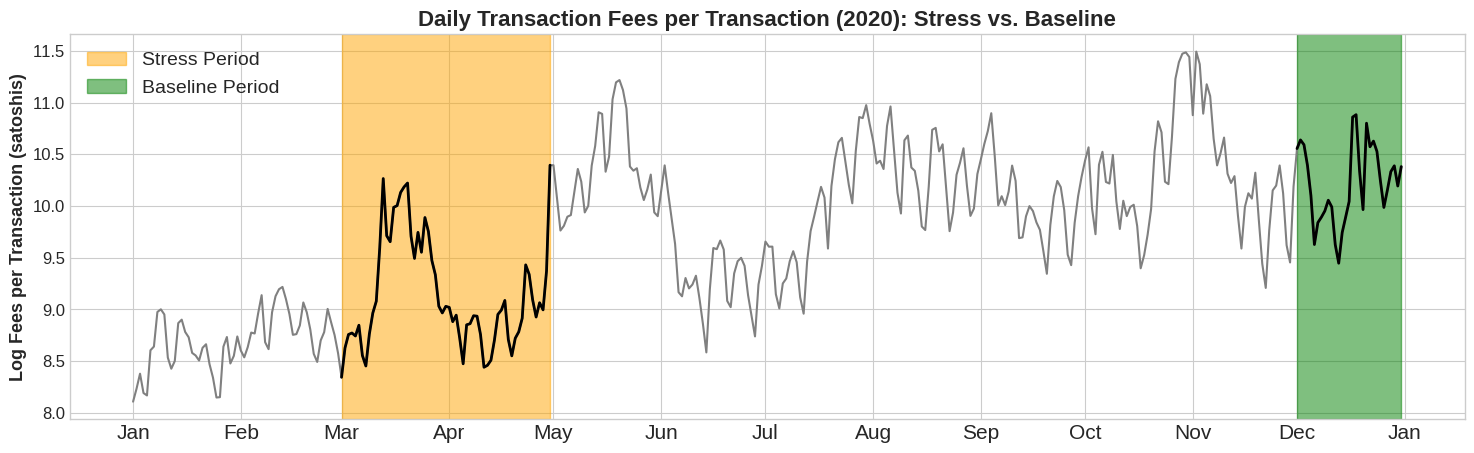

In [25]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(18,5))
plt.plot(data.index, data['fee_per_transaction'], color='grey')

plt.title('Daily Transaction Fees per Transaction (2020): Stress vs. Baseline', fontsize=16, fontweight='bold')
plt.ylabel('Log Fees per Transaction (satoshis)', fontsize=13, fontweight='bold')
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator()) # forces tick at every month boundary
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.plot(stress.index, stress['fee_per_transaction'], color='black', linewidth=2)
plt.plot(base.index, base['fee_per_transaction'], color='black', linewidth=2)

plt.axvspan('2020-03-01', '2020-04-30', color='orange', alpha=0.5, label='Stress Period')
plt.axvspan('2020-12-01', '2020-12-31', color='green', alpha=0.5, label='Baseline Period')

plt.legend(fontsize=14)
plt.show()

#### Transaction Counts per Block

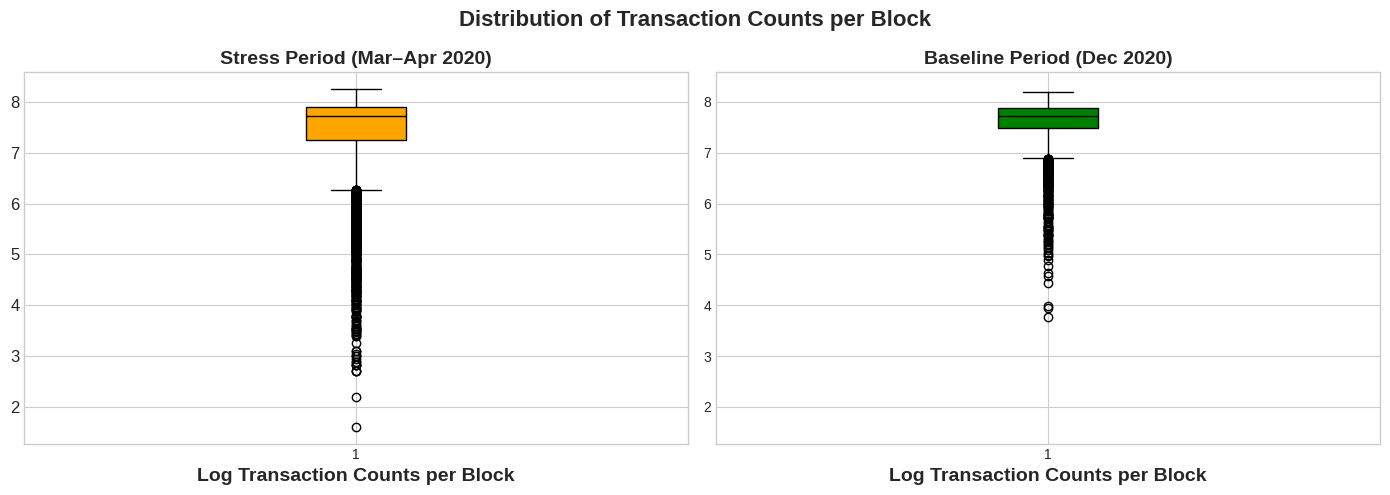

In [30]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,5), sharey=True)

fig.suptitle(
    'Distribution of Transaction Counts per Block',
    fontsize=16,
    fontweight='bold'
)

axes[0].boxplot(march_april['transaction_count'], patch_artist=True,
            boxprops=dict(facecolor='orange'), medianprops=dict(color='black'))
axes[0].set_title('Stress Period (Mar–Apr 2020)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Log Transaction Counts per Block', fontsize=14, fontweight='bold')
axes[0].tick_params('y', labelsize=12)

axes[1].boxplot(baseline['transaction_count'], patch_artist=True,
            boxprops=dict(facecolor='green'), medianprops=dict(color='black'))
axes[1].set_title('Baseline Period (Dec 2020)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log Transaction Counts per Block', fontsize=14, fontweight='bold')
axes[0].tick_params('y', labelsize=12)
axes[1].tick_params(labelleft=True)

plt.tight_layout()
plt.show()

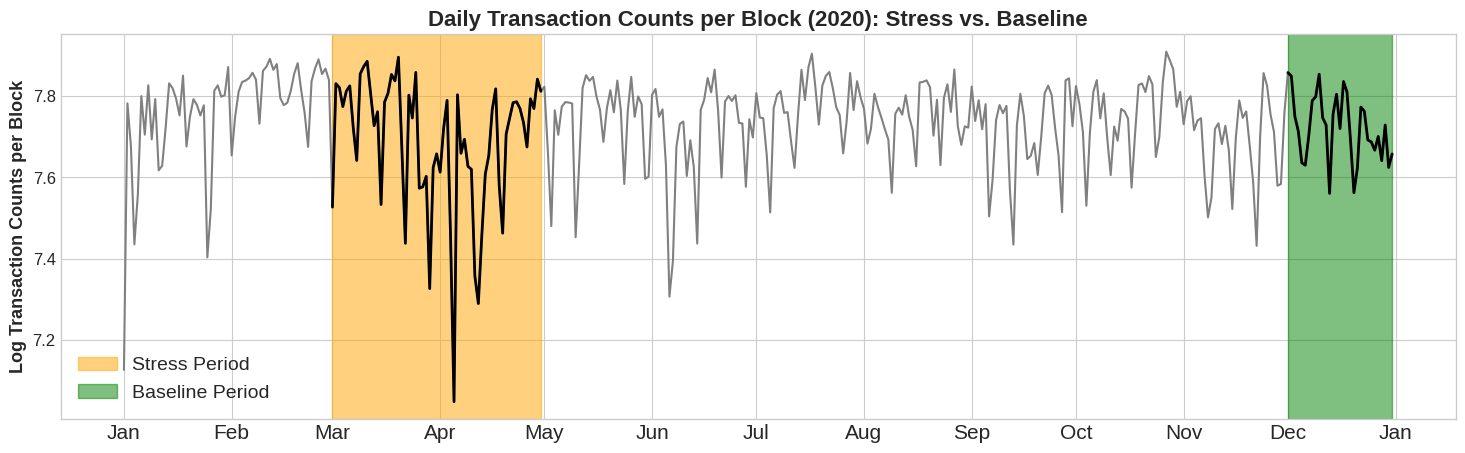

In [23]:
plt.figure(figsize=(18,5))
plt.plot(data.index, data['transaction_count'], color='grey')

plt.title('Daily Transaction Counts per Block (2020): Stress vs. Baseline', fontsize=16, fontweight='bold')
plt.ylabel('Log Transaction Counts per Block', fontsize=13, fontweight='bold')
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator()) # forces tick at every month boundary
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.plot(stress.index, stress['transaction_count'], color='black', linewidth=2)
plt.plot(base.index, base['transaction_count'], color='black', linewidth=2)

plt.axvspan('2020-03-01', '2020-04-30', color='orange', alpha=0.5, label='Stress Period')
plt.axvspan('2020-12-01', '2020-12-31', color='green', alpha=0.5, label='Baseline Period')

plt.legend(fontsize=14, loc='lower left')
plt.show()

####Block Utilization

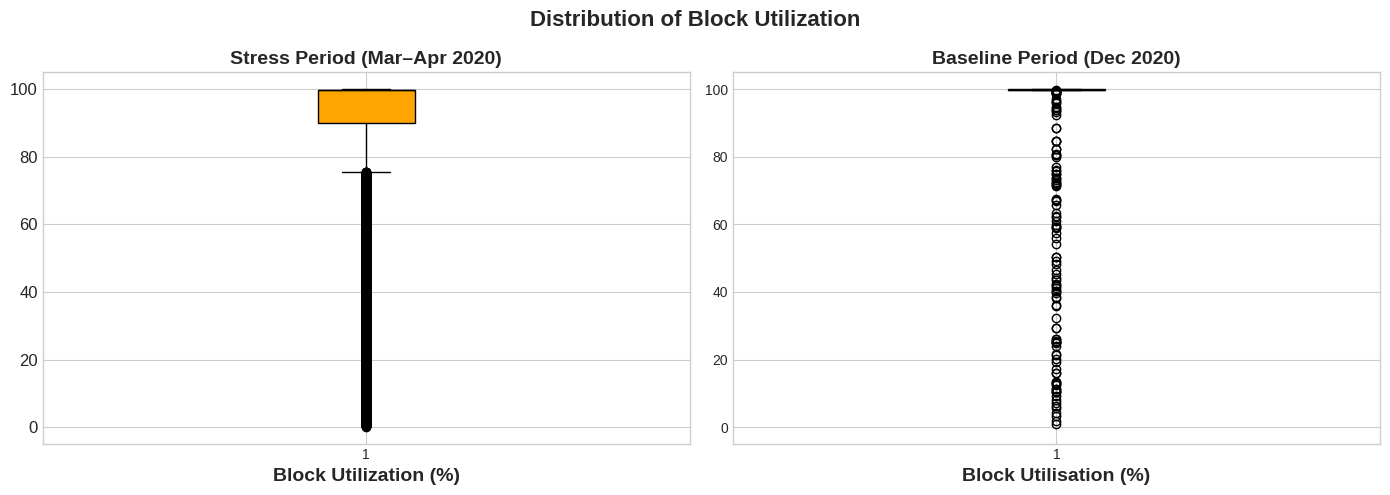

In [29]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,5), sharey=True)

fig.suptitle(
    'Distribution of Block Utilization',
    fontsize=16,
    fontweight='bold'
)

axes[0].boxplot(march_april['block_utilization'], patch_artist=True,
            boxprops=dict(facecolor='orange'), medianprops=dict(color='black'))
axes[0].set_title('Stress Period (Mar–Apr 2020)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Block Utilization (%)', fontsize=14, fontweight='bold')
axes[0].tick_params('y', labelsize=12)

axes[1].boxplot(baseline['block_utilization'], patch_artist=True,
            boxprops=dict(facecolor='green'), medianprops=dict(color='black'))
axes[1].set_title('Baseline Period (Dec 2020)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Block Utilisation (%)', fontsize=14, fontweight='bold')
axes[0].tick_params('y', labelsize=12)
axes[1].tick_params(labelleft=True)

plt.tight_layout()
plt.show()

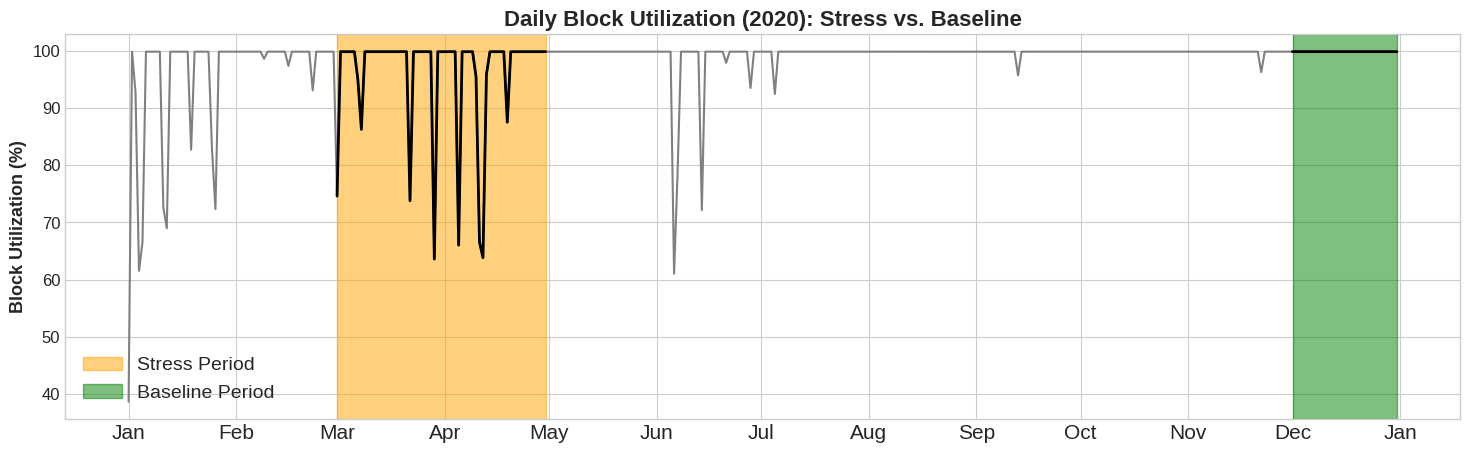

In [28]:
plt.figure(figsize=(18,5))
plt.plot(data.index, data['block_utilization'], color='grey')

plt.title('Daily Block Utilization (2020): Stress vs. Baseline', fontsize=16, fontweight='bold')
plt.ylabel('Block Utilization (%)', fontsize=13, fontweight='bold')
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator()) # forces tick at every month boundary
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.plot(stress.index, stress['block_utilization'], color='black', linewidth=2)
plt.plot(base.index, base['block_utilization'], color='black', linewidth=2)

plt.axvspan('2020-03-01', '2020-04-30', color='orange', alpha=0.5, label='Stress Period')
plt.axvspan('2020-12-01', '2020-12-31', color='green', alpha=0.5, label='Baseline Period')

plt.legend(fontsize=14, loc='lower left')
plt.show()

## Volatility

### GARCH Models

In [ ]:
pip install arch

In [32]:
march_april.columns

Index(['id', 'hash', 'time', 'block_time_secs', 'median_time', 'size',
       'stripped_size', 'weight', 'version', 'version_hex', 'version_bits',
       'merkle_root', 'nonce', 'bits', 'difficulty', 'chainwork',
       'coinbase_data_hex', 'transaction_count', 'witness_count',
       'input_count', 'output_count', 'input_total', 'input_total_usd',
       'output_total', 'output_total_usd', 'fee_total', 'fee_total_usd',
       'fee_per_kb', 'fee_per_kb_usd', 'fee_per_kwu', 'fee_per_kwu_usd',
       'cdd_total', 'generation', 'generation_usd', 'reward', 'reward_usd',
       'guessed_miner', 'bitcoin_price_usd', 'fee_per_transaction',
       'block_utilization'],
      dtype='object')

In [33]:
march_april_Read = march_april.copy()
'''
First difference as the variables are already in log levels
'''
march_april_Read['fee_per_transaction'] = march_april_Read['fee_per_transaction'].diff().dropna()
march_april_Read['transaction_count'] = march_april_Read['transaction_count'].diff().dropna()

baseline_Read = baseline.copy()
baseline_Read['fee_per_transaction'] = baseline_Read['fee_per_transaction'].diff().dropna()
baseline_Read['transaction_count'] = baseline_Read['transaction_count'].diff().dropna()

In [34]:
march_april_Read.drop(index=8891, inplace=True)
march_april_Read.reset_index(drop=True, inplace=True)

In [35]:
baseline_Read.drop(index=48708, inplace=True)
baseline_Read.reset_index(drop=True, inplace=True)

In [36]:
from arch import arch_model

# Transaction Fees per Transactation
stress_fee_garch = arch_model(march_april_Read['fee_per_transaction'], vol='GARCH', p=1, q=1, mean='Zero')
baseline_fee_garch = arch_model(baseline_Read['fee_per_transaction'], vol='GARCH', p=1, q=1, mean='Zero')

# Transaction Activity (Count)
stress_activity_garch = arch_model(march_april_Read['transaction_count'], vol='GARCH', p=1, q=1, mean='Zero')
baseline_activity_garch = arch_model(baseline_Read['transaction_count'], vol='GARCH', p=1, q=1, mean='Zero')

In [37]:
res1 = stress_fee_garch.fit(disp='off')
res2 = baseline_fee_garch.fit(disp='off')
print(res1.summary())
print(res2.summary())

                        Zero Mean - GARCH Model Results                        
Dep. Variable:     fee_per_transaction   R-squared:                       0.000
Mean Model:                  Zero Mean   Adj. R-squared:                  0.000
Vol Model:                       GARCH   Log-Likelihood:               -8752.50
Distribution:                   Normal   AIC:                           17511.0
Method:             Maximum Likelihood   BIC:                           17532.2
                                         No. Observations:                 8738
Date:                 Thu, May 07 2026   Df Residuals:                     8738
Time:                         12:12:25   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.2005  2.858e-02      7.016  2.286e-12 

In [ ]:
cond_vol1 = res1.conditional_volatility
cond_vol2 = res2.conditional_volatility

In [ ]:
print(cond_vol1.describe())
print(cond_vol2.describe())

count    8738.000000
mean        0.684730
std         0.221644
min         0.510762
25%         0.542722
50%         0.600739
75%         0.735242
max         2.588102
Name: cond_vol, dtype: float64
count    4487.000000
mean        0.672307
std         0.225807
min         0.291931
25%         0.499445
50%         0.643706
75%         0.819462
max         1.634298
Name: cond_vol, dtype: float64


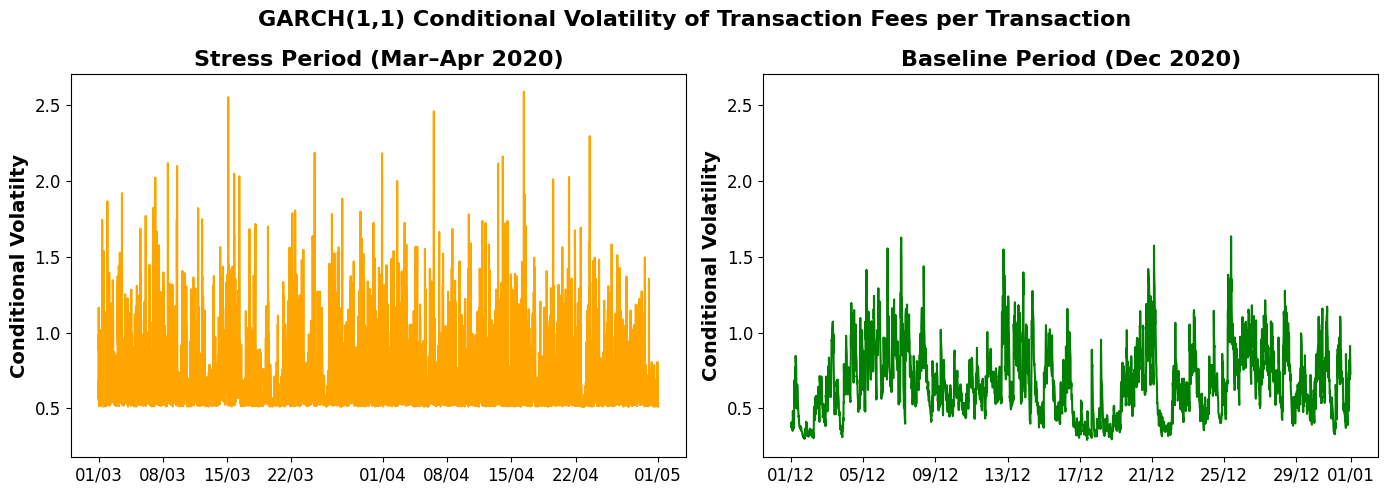

In [ ]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,5), sharey=True)

fig.suptitle(
    'GARCH(1,1) Conditional Volatility of Transaction Fees per Transaction',
    fontsize=16,
    fontweight='bold'
)

axes[0].plot(march_april_Read['time'], cond_vol1, color='orange')
axes[0].set_title('Stress Period (Mar–Apr 2020)', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Conditional Volatilty', fontsize=14, fontweight='bold')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
axes[0].tick_params(axis='y', labelsize=12)
axes[0].tick_params(axis='x', labelsize=12)

axes[1].plot(baseline_Read['time'], cond_vol2, color='green')
axes[1].set_title('Baseline Period (Dec 2020)', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Conditional Volatility', fontsize=14, fontweight='bold')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
axes[1].tick_params(axis='y', labelsize=12)
axes[1].tick_params(axis='x', labelsize=12)
axes[1].tick_params(labelleft=True)

plt.tight_layout()
plt.show()


In [ ]:
res1 = stress_activity_garch.fit(disp='off')
res2 = baseline_activity_garch.fit(disp='off')
print(res1.summary())
print(res2.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:      transaction_count   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -9632.69
Distribution:                  Normal   AIC:                           19271.4
Method:            Maximum Likelihood   BIC:                           19292.6
                                        No. Observations:                 8738
Date:                Thu, Apr 23 2026   Df Residuals:                     8738
Time:                        17:28:16   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0223  7.146e-03      3.116  1.833e-03 [8.

In [ ]:
cond_vol1 = res1.conditional_volatility
cond_vol2 = res2.conditional_volatility

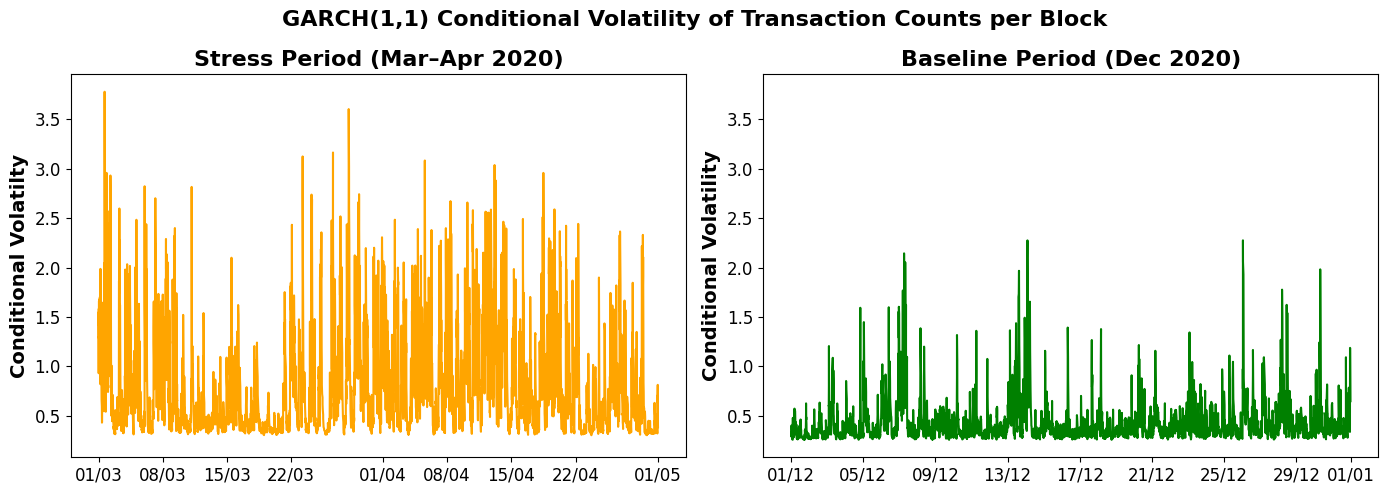

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,5), sharey=True)

fig.suptitle(
    'GARCH(1,1) Conditional Volatility of Transaction Counts per Block',
    fontsize=16,
    fontweight='bold'
)

axes[0].plot(march_april_Read['time'], cond_vol1, color='orange')
axes[0].set_title('Stress Period (Mar–Apr 2020)', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Conditional Volatilty', fontsize=14, fontweight='bold')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
axes[0].tick_params(axis='y', labelsize=12)
axes[0].tick_params(axis='x', labelsize=12)

axes[1].plot(baseline_Read['time'], cond_vol2, color='green')
axes[1].set_title('Baseline Period (Dec 2020)', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Conditional Volatility', fontsize=14, fontweight='bold')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
axes[1].tick_params(axis='y', labelsize=12)
axes[1].tick_params(axis='x', labelsize=12)
axes[1].tick_params(labelleft=True)

plt.tight_layout()
plt.show()

## Urgency Premium

**Urgency premium** in Bitcoin refers to the higher transaction fees users willingly pay to miners to ensure faster confirmation times during periods of high network activity (congestion).

A possible way to define this is to label as *priority* fees above the 3rd quartile within each period.

* Use `fee_total` as the objective is measuring priority in the fee market, not price volatility

In [ ]:
d.columns

Index(['id', 'hash', 'time', 'block_time_secs', 'median_time', 'size',
       'stripped_size', 'weight', 'version', 'version_hex', 'version_bits',
       'merkle_root', 'nonce', 'bits', 'difficulty', 'chainwork',
       'coinbase_data_hex', 'transaction_count', 'witness_count',
       'input_count', 'output_count', 'input_total', 'input_total_usd',
       'output_total', 'output_total_usd', 'fee_total', 'fee_total_usd',
       'fee_per_kb', 'fee_per_kb_usd', 'fee_per_kwu', 'fee_per_kwu_usd',
       'cdd_total', 'generation', 'generation_usd', 'reward', 'reward_usd',
       'guessed_miner', 'bitcoin_price_usd'],
      dtype='object')

In [ ]:
#d['fee_per_transaction'] = d['fee_total']/d['transaction_count']
d.head()

,id,hash,time,block_time_secs,median_time,size,stripped_size,weight,version,version_hex,...,fee_per_kb_usd,fee_per_kwu,fee_per_kwu_usd,cdd_total,generation,generation_usd,reward,reward_usd,guessed_miner,bitcoin_price_usd
0,610691,00000000000000000001cc49c6ebb2e7546615e1f16816...,2020-01-01 00:03:00,NaN,2019-12-31 23:07:00,1250129,914500,3993629,549453824,20c00000,...,1.0096,4392.34,0.3160,17164.324800,1250000000,89939.375,1267534026,91200.9766,Unknown,7130.40
1,610692,000000000000000000117f1821db8f36e05a70ed9dbffa...,2020-01-01 00:07:00,267.0,2019-12-31 23:13:00,661706,424345,1934741,536870912,20000000,...,0.6010,2857.26,0.2056,2792.642387,1250000000,89939.375,1255524017,90336.8359,Unknown,7130.42
2,610693,00000000000000000014a2d6530192263dffbb1723acc9...,2020-01-01 00:13:00,362.0,2019-12-31 23:22:00,436344,284543,1289973,1073733632,3fffe000,...,0.7130,3352.70,0.2413,6755.644735,1250000000,89939.375,1254319091,90250.1406,F2Pool,7133.45
3,610694,000000000000000000053ba498a77d2e186a0d530abe5c...,2020-01-01 00:19:00,326.0,2019-12-31 23:37:00,467181,285676,1324209,1073733632,3fffe000,...,0.4280,2099.23,0.1510,564.570718,1250000000,89939.375,1252776912,90139.1797,Unknown,7142.20
4,610695,00000000000000000009ae968a937bea55223270e64058...,2020-01-01 00:37:00,1112.0,2019-12-31 23:41:00,1123752,758667,3399753,545259520,20800000,...,0.5617,2580.31,0.1856,35967.771680,1250000000,89939.375,1258768740,90570.2969,AntPool,7148.87


In [ ]:
start = pd.to_datetime('01-03-2020', dayfirst=True)
end = pd.to_datetime('01-05-2020', dayfirst=True)
stress_urgency = d[(d['time'] >= start) & (d['time'] <= end)]

start = pd.to_datetime('01-12-2020', dayfirst=True)
end = pd.to_datetime('01-01-2021', dayfirst=True)
baseline_urgency = d[(d['time'] >= start) & (d['time'] <= end)]

In [ ]:
print(stress_urgency['time'].max())
print(baseline_urgency['time'].max())

2020-04-30 23:51:00
2020-12-31 23:57:00


In [ ]:
print(round(stress_urgency['fee_per_kwu'].describe(),2))
print(round(baseline_urgency['fee_per_kwu'].describe(),2))

count     8768.00
mean      6577.67
std       5379.70
min          0.00
25%       3119.54
50%       4870.83
75%       8030.73
max      66573.50
Name: fee_per_kwu, dtype: float64
count      4514.00
mean      17037.21
std       10181.71
min           0.00
25%        8417.40
50%       15967.25
75%       24647.25
max      102036.00
Name: fee_per_kwu, dtype: float64


In [ ]:
q75_s = stress_urgency['fee_per_kwu'].quantile(0.75)
stress_urgency_priority = stress_urgency[stress_urgency['fee_per_kwu'] > q75_s]
stress_urgency_np = stress_urgency[stress_urgency['fee_per_kwu'] <= q75_s]

q75_b = baseline_urgency['fee_per_kwu'].quantile(0.75)
baseline_urgency_priority = baseline_urgency[baseline_urgency['fee_per_kwu'] > q75_b]
baseline_urgency_np = baseline_urgency[baseline_urgency['fee_per_kwu'] <= q75_b]

In [ ]:
print(stress_urgency.shape[0])
print(stress_urgency_priority.shape[0])
print(stress_urgency_np.shape[0])

print(baseline_urgency.shape[0])
print(baseline_urgency_priority.shape[0])
print(baseline_urgency_np.shape[0])

8768
2192
6576
4514
1129
3385


In [ ]:
stress_premium = stress_urgency_priority['fee_per_kwu'].median()/stress_urgency_np['fee_per_kwu'].median()

baseline_premium = baseline_urgency_priority['fee_per_kwu'].median()/baseline_urgency_np['fee_per_kwu'].median()

In [ ]:
print(round(stress_premium,2))
print(round(baseline_premium,2))
#print(round(stress_premium - baseline_premium,2)) # users paid a lower urgency premium during the stress period

3.22
2.53


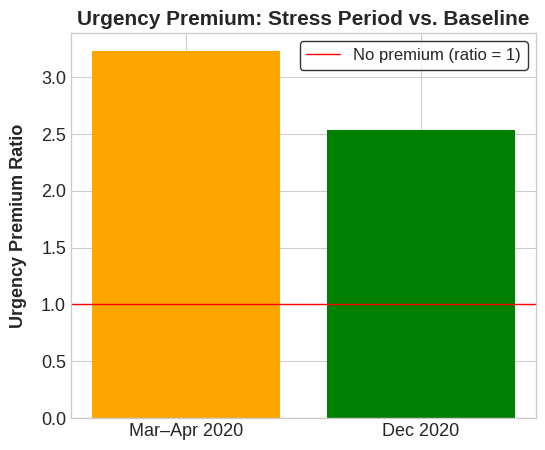

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(6,5))

plt.bar(['Mar–Apr 2020', 'Dec 2020'], [stress_premium, baseline_premium], color=['orange','green'])
plt.axhline(y=1.0, color='red', linestyle='-', linewidth=1, label='No premium (ratio = 1)')

plt.ylabel('Urgency Premium Ratio', fontsize=13, fontweight='bold', labelpad=10)
plt.title('Urgency Premium: Stress Period vs. Baseline', fontsize=15, fontweight='bold')
plt.tick_params('x', labelsize=13)
plt.tick_params('y', labelsize=13)
plt.legend(
    loc='upper right',
    fontsize=12,
    frameon=True,
    facecolor='white',
    edgecolor='black'
)
plt.show()

## Crypto Fear & Greed Index

In [ ]:
index = pd.read_csv('CryptoFear&GreedIndex.csv')
index.head()

,Date,Value,Value_Classification,BTC_Closing,BTC_Volume
0,2018-02-01,30.0,Fear,9170.540039,9959400448
1,2018-02-02,15.0,Extreme Fear,8830.750000,12726899712
2,2018-02-03,40.0,Fear,9174.910156,7263790080
3,2018-02-04,24.0,Extreme Fear,8277.009766,7073549824
4,2018-02-05,11.0,Extreme Fear,6955.270020,9285289984


In [ ]:
index['Date'] = pd.to_datetime(index['Date'], yearfirst=True)
index['Date'].max()

Timestamp('2023-03-31 00:00:00')

In [ ]:
index = index[(index['Date'] >= '2019-12-31') & (index['Date'] <= '2020-12-31')]
index.head()

,Date,Value,Value_Classification,BTC_Closing,BTC_Volume
698,2019-12-31,38.0,Fear,7193.599121,21167946112
699,2020-01-01,37.0,Fear,7200.174316,18565664997
700,2020-01-02,39.0,Fear,6985.470215,20802083465
701,2020-01-03,38.0,Fear,7344.884277,28111481032
702,2020-01-04,38.0,Fear,7410.656738,18444271275


In [ ]:
index.tail()

,Date,Value,Value_Classification,BTC_Closing,BTC_Volume
1060,2020-12-27,91.0,Extreme Greed,26272.294922,66479895605
1061,2020-12-28,92.0,Extreme Greed,27084.808594,49056742893
1062,2020-12-29,91.0,Extreme Greed,27362.437500,45265946774
1063,2020-12-30,91.0,Extreme Greed,28840.953125,51287442704
1064,2020-12-31,95.0,Extreme Greed,29001.720703,46754964848


In [ ]:
indexRead = index.copy()
indexRead.set_index('Date', inplace=True, drop=True)
indexRead_numerical = indexRead.select_dtypes(include=np.number).resample('ME').median()

def classify_value(value):
    if 0 <= value <= 24:
        return 'Extreme Fear'
    elif 25 <= value <= 49:
        return 'Fear'
    elif 50 <= value <= 59:
        return 'Neutral'
    elif 60 <= value <= 79:
        return 'Greed'
    elif 80 <= value <= 100:
        return 'Extreme Greed'
    else:
        return None


indexRead_numerical['Value_Classification'] = indexRead_numerical['Value'].apply(classify_value)
indexRead = indexRead_numerical

In [ ]:
indexRead.head()

,Value,BTC_Closing,BTC_Volume,Value_Classification
Date,,,,
2019-12-31,38.0,7193.599121,2.116795e+10,Fear
2020-01-31,49.0,8445.434570,2.642238e+10,Fear
2020-02-29,53.0,9686.441406,4.118519e+10,Neutral
2020-03-31,12.0,6438.644531,3.997310e+10,Extreme Fear
2020-04-30,16.5,7117.005859,3.528735e+10,Extreme Fear


In [ ]:
indexRead.drop(index='2019-12-31', inplace=True)
indexRead.reset_index(inplace=True)
indexRead.head()

,Date,Value,BTC_Closing,BTC_Volume,Value_Classification
0,2020-01-31,49.0,8445.434570,2.642238e+10,Fear
1,2020-02-29,53.0,9686.441406,4.118519e+10,Neutral
2,2020-03-31,12.0,6438.644531,3.997310e+10,Extreme Fear
3,2020-04-30,16.5,7117.005859,3.528735e+10,Extreme Fear
4,2020-05-31,42.0,9268.761719,4.013439e+10,Fear


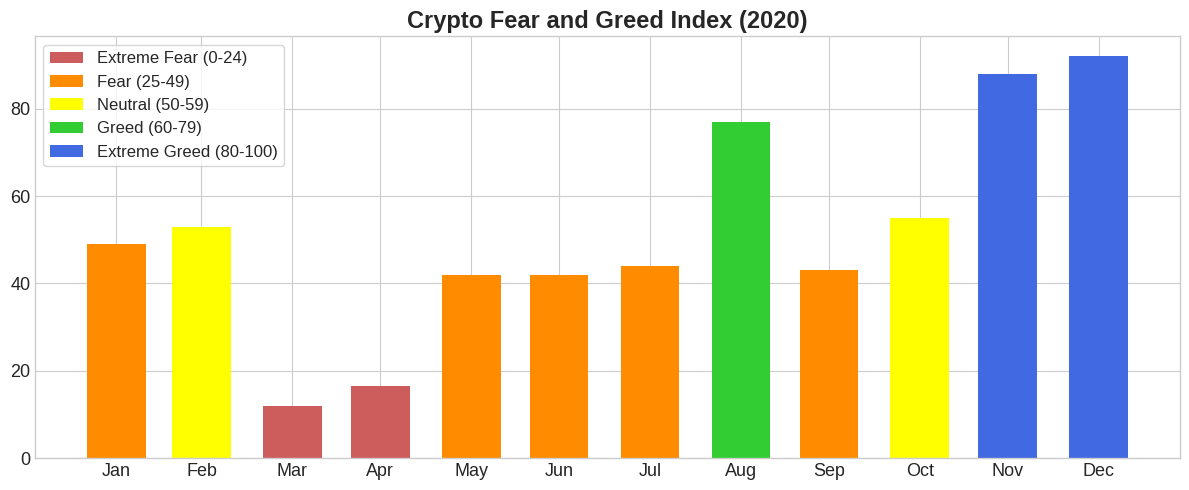

In [ ]:
import matplotlib.dates as mdates
from matplotlib.patches import Patch

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(12, 5))

color_map = {
    'Extreme Fear (0-24)': 'indianred',
    'Fear (25-49)': 'darkorange',
    'Neutral (50-59)': 'yellow',
    'Greed (60-79)': 'limegreen',
    'Extreme Greed (80-100)': 'royalblue'
}

colors = indexRead['Value_Classification'].map({
    'Extreme Fear': 'indianred',
    'Fear': 'darkorange',
    'Neutral': 'yellow',
    'Greed': 'limegreen',
    'Extreme Greed': 'royalblue'
})

ax.bar(
    indexRead['Date'],
    indexRead['Value'],
    color=colors,
    width=20
)

ax.set_xticks(indexRead['Date'])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

ax.legend(
    handles=[Patch(facecolor=color_map[k], label=k) for k in color_map],
    fontsize=12,
    loc='upper left',
    frameon=True
)

plt.title('Crypto Fear and Greed Index (2020)', fontsize=17, fontweight='bold')

plt.tick_params('x', rotation=0, labelsize=13)
plt.tick_params('y', labelsize=13)
plt.tight_layout()
plt.show()

# Question 5

**Q5 – Is Bitcoin gradually transitioning toward a fee-supported security model?**

Bitcoin’s long-term design assumes that transaction fees will eventually replace block subsidies as the primary incentive for miners. Using the dataset, analyse how the share of miner revenue coming from transaction fees has evolved from 2020 to 2025 and how this share behaves during periods of elevated network demand. Quantify whether fee reliance increases steadily over time or primarily during congestion episodes. Compare the stability and volatility of fee income relative to block reward income. Use external sources on mining economics and protocol design to assess whether observed fee dynamics appear consistent with long-run security expectations.

## Fee Share of Miner Revenue Evolution

### Fee Share Study

Keep in mind that:

*   Reward = Block Subsidy + Transaction Fees (in satoshis)




In [ ]:
print(d['time'].min())
print(d['time'].max())

2020-01-01 00:03:00
2025-12-31 23:59:00


In [ ]:
d.columns

Index(['id', 'hash', 'time', 'block_time_secs', 'median_time', 'size',
       'stripped_size', 'weight', 'version', 'version_hex', 'version_bits',
       'merkle_root', 'nonce', 'bits', 'difficulty', 'chainwork',
       'coinbase_data_hex', 'transaction_count', 'witness_count',
       'input_count', 'output_count', 'input_total', 'input_total_usd',
       'output_total', 'output_total_usd', 'fee_total', 'fee_total_usd',
       'fee_per_kb', 'fee_per_kb_usd', 'fee_per_kwu', 'fee_per_kwu_usd',
       'cdd_total', 'generation', 'generation_usd', 'reward', 'reward_usd',
       'guessed_miner', 'bitcoin_price_usd'],
      dtype='object')

In [ ]:
'''
 d['generation'] = block subsidy > values not in BTC but in satoshis

 1 BTC = 100,000,000 satoshis
'''

"\n d['generation'] = block subsidy > values not in BTC but in satoshis\n\n 1 BTC = 100,000,000 satoshis\n"

In [ ]:
# d['reward'] = total reward
d['fee_share'] = d['fee_total']/d['reward']*100 #satoshis --> right skewness
d['fee_share_log'] = np.log1p(d['fee_total']/d['reward']*100) #satoshis --> right skewness
d['block_subsidy_share'] = d['generation']/d['reward']*100 #satoshis --> left skewness
d['block_subsidy_share_log'] = np.log1p(d['generation']/d['reward']*100) #satoshis --> left skewness

In [ ]:
print(d['fee_total'].describe())
print(d['reward'].describe())
print(d['fee_share'].describe())
print(d['block_subsidy_share'].describe())

count    3.196480e+05
mean     2.924779e+07
std      5.426190e+07
min      0.000000e+00
25%      4.346430e+06
50%      1.181188e+07
75%      3.096775e+07
max      8.521634e+09
Name: fee_total, dtype: float64
count    3.196480e+05
mean     6.036834e+08
std      2.330602e+08
min      3.125000e+08
25%      3.279327e+08
50%      6.356748e+08
75%      6.638828e+08
max      9.146634e+09
Name: reward, dtype: float64
count    319648.000000
mean          4.281188
std           5.911456
min           0.000000
25%           0.933059
50%           2.067453
75%           4.956801
max          93.166885
Name: fee_share, dtype: float64
count    319648.000000
mean         95.718812
std           5.911456
min           6.833115
25%          95.043199
50%          97.932547
75%          99.066941
max         100.000000
Name: block_subsidy_share, dtype: float64


In [ ]:
dRead = d.copy()

dRead.set_index('time', drop=True, inplace=True)
dRead.drop(columns=dRead.select_dtypes(include='object').columns, inplace=True)
dRead = dRead.resample('M').median()
dRead.head()

/tmp/ipykernel_2065/3493888699.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dRead = dRead.resample('M').median()


,id,block_time_secs,median_time,size,stripped_size,weight,version,version_bits,nonce,bits,...,cdd_total,generation,generation_usd,reward,reward_usd,bitcoin_price_usd,fee_share,fee_share_log,block_subsidy_share,block_subsidy_share_log
time,,,,,,,,,,,,,,,,,,,,,
2020-01-31,613059.0,387.0,2020-01-16 06:46:00,1187957.0,871075.0,3993060.0,541065216.0,1.000000e+29,1.779685e+09,387124344.0,...,12049.482380,1.250000e+09,104779.6250,1.260545e+09,105611.28910,8355.180,0.836548,0.607888,99.163452,4.606803
2020-02-29,617504.5,427.0,2020-02-15 14:11:30,1241537.0,887200.0,3993243.0,541065216.0,1.000000e+29,1.871908e+09,387067068.0,...,15669.802965,1.250000e+09,120905.6250,1.266120e+09,122871.84765,9696.350,1.273149,0.821166,98.726851,4.602435
2020-03-31,621709.0,436.0,2020-03-15 09:07:00,1239839.0,888710.0,3993231.0,541065216.0,1.000000e+29,1.838262e+09,387067068.0,...,16991.353070,1.250000e+09,83763.3750,1.270937e+09,85284.78120,6646.320,1.647331,0.973552,98.352669,4.598676
2020-04-30,626093.0,399.0,2020-04-15 09:46:00,1222899.0,895257.0,3993232.0,541065216.0,1.000000e+29,1.825375e+09,387129532.0,...,10937.619730,1.250000e+09,87928.6250,1.263687e+09,88896.03120,7067.900,1.083113,0.733863,98.916887,4.604339
2020-05-31,630445.5,441.5,2020-05-15 07:13:00,1284538.5,898288.0,3993341.0,541065216.0,1.000000e+29,1.802458e+09,387031859.0,...,17468.079035,6.250000e+08,60264.9336,7.802626e+08,74177.19140,9184.985,6.827507,2.057644,93.172493,4.545128


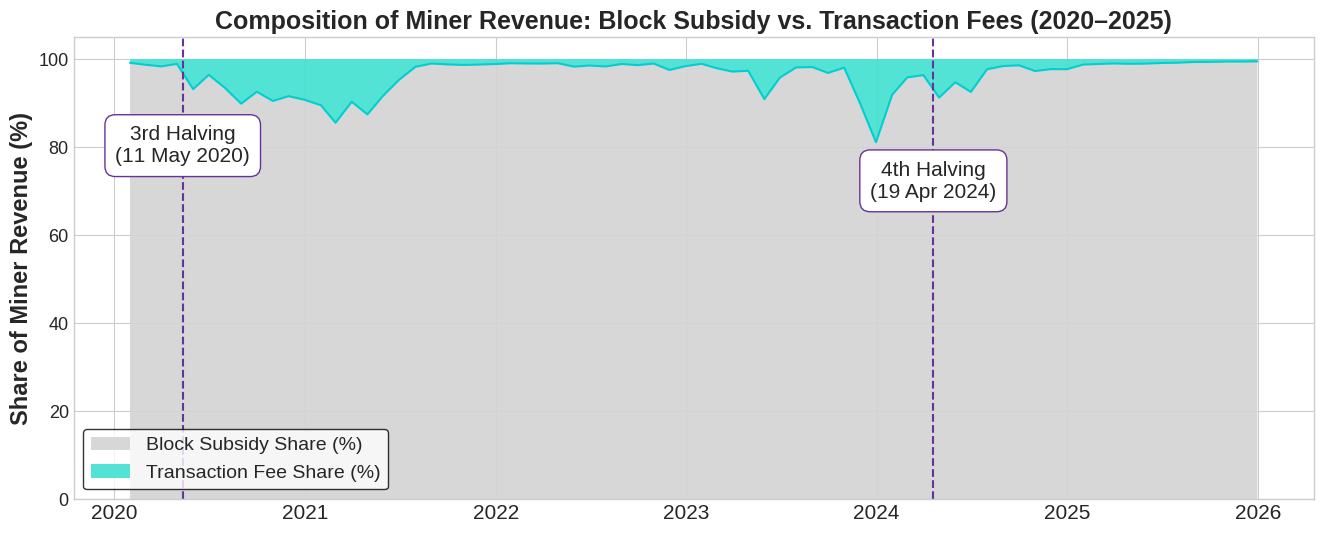

In [ ]:
import matplotlib.dates as mdates

plt.figure(figsize=(16, 6))

plt.stackplot(
    dRead.index,
    dRead['block_subsidy_share'],
    dRead['fee_share'],
    labels=['Block Subsidy Share (%)', 'Transaction Fee Share (%)'],
    colors=['#D3D3D3', '#40E0D0'],
    alpha=0.9
)

boundary = dRead['block_subsidy_share']

plt.style.use('seaborn-v0_8-whitegrid')

plt.plot(
    dRead.index,
    boundary,
    color='darkturquoise',
    linewidth=1.5
)

plt.axvline(pd.Timestamp('2020-05-11'), color='rebeccapurple', linestyle='--', linewidth=1.5)
plt.axvline(pd.Timestamp('2024-04-19'), color='rebeccapurple', linestyle='--', linewidth=1.5)

plt.text(pd.Timestamp('2020-05-11'), 85,
         '3rd Halving\n(11 May 2020)',
         va='top', ha='center',
         fontsize=15,
         bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='rebeccapurple', alpha=1))

plt.text(pd.Timestamp('2024-04-19'), 77,
         '4th Halving\n(19 Apr 2024)',
         va='top', ha='center',
         fontsize=15,
         bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='rebeccapurple', alpha=1))

plt.title('Composition of Miner Revenue: Block Subsidy vs. Transaction Fees (2020–2025)', fontsize=18, fontweight='bold')
plt.ylabel('Share of Miner Revenue (%)', fontsize=17, fontweight='bold')
plt.tick_params('x', labelsize=15)
plt.tick_params('y', labelsize=13)

plt.legend(
    loc='lower left',
    fontsize=14,
    frameon=True,
    facecolor='white',
    edgecolor='black'
)

plt.grid(True)
plt.show()

In [ ]:
dRead = d.copy()

dRead['year'] = dRead['time'].dt.year

dRead_2020 = dRead[dRead['year'] == 2020]
dRead_2021 = dRead[dRead['year'] == 2021]
dRead_2022 = dRead[dRead['year'] == 2022]
dRead_2023 = dRead[dRead['year'] == 2023]
dRead_2024 = dRead[dRead['year'] == 2024]
dRead_2025 = dRead[dRead['year'] == 2025]

print(round(dRead_2020['fee_share_log'].describe(),3))
print(round(dRead_2021['fee_share_log'].describe(),3))
print(round(dRead_2022['fee_share_log'].describe(),3))
print(round(dRead_2023['fee_share_log'].describe()),3)
print(round(dRead_2024['fee_share_log'].describe()),3)
print(round(dRead_2025['fee_share_log'].describe()),3)

count    53222.000
mean         1.613
std          0.887
min          0.000
25%          0.864
50%          1.610
75%          2.372
max          3.700
Name: fee_share_log, dtype: float64
count    52686.000
mean         1.507
std          0.900
min          0.000
25%          0.741
50%          1.361
75%          2.358
max          3.598
Name: fee_share_log, dtype: float64
count    53188.000
mean         0.831
std          0.471
min          0.000
25%          0.450
50%          0.808
75%          1.184
max          3.648
Name: fee_share_log, dtype: float64
count    53999.0
mean         2.0
std          1.0
min          0.0
25%          1.0
50%          1.0
75%          2.0
max          5.0
Name: fee_share_log, dtype: float64 3
count    53471.0
mean         2.0
std          1.0
min          0.0
25%          1.0
50%          1.0
75%          2.0
max          5.0
Name: fee_share_log, dtype: float64 3
count    53082.0
mean         1.0
std          0.0
min          0.0
25%          0.0
50%

In [ ]:
dRead.head()

,id,hash,time,block_time_secs,median_time,size,stripped_size,weight,version,version_hex,...,generation_usd,reward,reward_usd,guessed_miner,bitcoin_price_usd,fee_share,fee_share_log,block_subsidy_share,block_subsidy_share_log,year
0,610691,00000000000000000001cc49c6ebb2e7546615e1f16816...,2020-01-01 00:03:00,NaN,2019-12-31 23:07:00,1250129,914500,3993629,549453824,20c00000,...,89939.375,1267534026,91200.9766,Unknown,7130.40,1.383318,0.868494,98.616682,4.601330,2020
1,610692,000000000000000000117f1821db8f36e05a70ed9dbffa...,2020-01-01 00:07:00,267.0,2019-12-31 23:13:00,661706,424345,1934741,536870912,20000000,...,89939.375,1255524017,90336.8359,Unknown,7130.42,0.439977,0.364627,99.560023,4.610755,2020
2,610693,00000000000000000014a2d6530192263dffbb1723acc9...,2020-01-01 00:13:00,362.0,2019-12-31 23:22:00,436344,284543,1289973,1073733632,3fffe000,...,89939.375,1254319091,90250.1406,F2Pool,7133.45,0.344338,0.295901,99.655662,4.611705,2020
3,610694,000000000000000000053ba498a77d2e186a0d530abe5c...,2020-01-01 00:19:00,326.0,2019-12-31 23:37:00,467181,285676,1324209,1073733632,3fffe000,...,89939.375,1252776912,90139.1797,Unknown,7142.20,0.221661,0.200211,99.778339,4.612923,2020
4,610695,00000000000000000009ae968a937bea55223270e64058...,2020-01-01 00:37:00,1112.0,2019-12-31 23:41:00,1123752,758667,3399753,545259520,20800000,...,89939.375,1258768740,90570.2969,AntPool,7148.87,0.696612,0.528634,99.303388,4.608199,2020


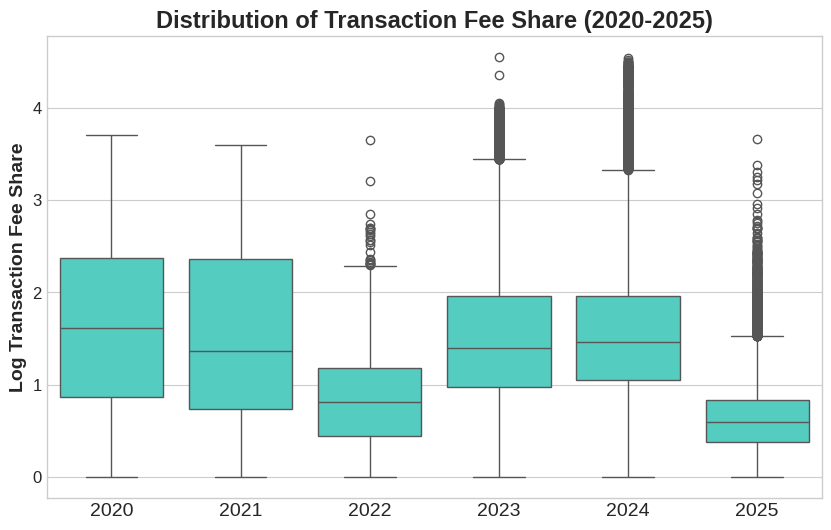

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=dRead, x='year', y='fee_share_log', color='#40E0D0')

plt.title('Distribution of Transaction Fee Share (2020-2025)', fontsize=17, fontweight='bold')
plt.ylabel('Log Transaction Fee Share', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.tick_params('x', labelsize=14)
plt.tick_params('y', labelsize=12)
plt.show()

### Fee Share in High Network Demand

In [ ]:
d['high_net_demand'] = (d['fee_per_kwu'] > d['fee_per_kwu'].quantile(0.75)).astype(int)

d.head()

,id,hash,time,block_time_secs,median_time,size,stripped_size,weight,version,version_hex,...,generation_usd,reward,reward_usd,guessed_miner,bitcoin_price_usd,fee_share,fee_share_log,block_subsidy_share,block_subsidy_share_log,high_net_demand
0,610691,00000000000000000001cc49c6ebb2e7546615e1f16816...,2020-01-01 00:03:00,NaN,2019-12-31 23:07:00,1250129,914500,3993629,549453824,20c00000,...,89939.375,1267534026,91200.9766,Unknown,7130.40,1.383318,0.868494,98.616682,4.601330,0
1,610692,000000000000000000117f1821db8f36e05a70ed9dbffa...,2020-01-01 00:07:00,267.0,2019-12-31 23:13:00,661706,424345,1934741,536870912,20000000,...,89939.375,1255524017,90336.8359,Unknown,7130.42,0.439977,0.364627,99.560023,4.610755,0
2,610693,00000000000000000014a2d6530192263dffbb1723acc9...,2020-01-01 00:13:00,362.0,2019-12-31 23:22:00,436344,284543,1289973,1073733632,3fffe000,...,89939.375,1254319091,90250.1406,F2Pool,7133.45,0.344338,0.295901,99.655662,4.611705,0
3,610694,000000000000000000053ba498a77d2e186a0d530abe5c...,2020-01-01 00:19:00,326.0,2019-12-31 23:37:00,467181,285676,1324209,1073733632,3fffe000,...,89939.375,1252776912,90139.1797,Unknown,7142.20,0.221661,0.200211,99.778339,4.612923,0
4,610695,00000000000000000009ae968a937bea55223270e64058...,2020-01-01 00:37:00,1112.0,2019-12-31 23:41:00,1123752,758667,3399753,545259520,20800000,...,89939.375,1258768740,90570.2969,AntPool,7148.87,0.696612,0.528634,99.303388,4.608199,0


In [ ]:
print(d.shape[0])
print((d['high_net_demand'] == 1).sum())
print((d['high_net_demand'] == 0).sum())

319648
79912
239736


In [ ]:
high_demand = d[d['high_net_demand'] == 1]
high_demand.head()

,id,hash,time,block_time_secs,median_time,size,stripped_size,weight,version,version_hex,...,generation_usd,reward,reward_usd,guessed_miner,bitcoin_price_usd,fee_share,fee_share_log,block_subsidy_share,block_subsidy_share_log,high_net_demand
79,610770,0000000000000000000c0f2cc61ade020f0f8cde23c901...,2020-01-01 13:18:00,978.0,2020-01-01 12:26:00,1032629,986905,3993344,545259520,20800000,...,89939.375,1300886808,93600.7578,AntPool,7173.25,3.911701,1.591620,96.088299,4.575621,1
231,610922,00000000000000000013079d3fc0599020e4b9015936a2...,2020-01-02 10:07:00,4267.0,2020-01-02 08:28:00,1245703,917681,3998746,536870912,20000000,...,89930.125,1294355236,93121.2266,F2Pool,7114.76,3.426821,1.487682,96.573179,4.580603,1
255,610946,0000000000000000000117860777e1533e4aa1cf24d0d0...,2020-01-02 13:09:00,825.0,2020-01-02 12:36:00,1024024,989759,3993301,545259520,20800000,...,89930.125,1309389096,94202.8203,AntPool,7090.51,4.535634,1.711206,95.464366,4.569174,1
350,611041,0000000000000000000d6594fa90c73aa5b5334e1856f8...,2020-01-03 04:28:00,54.0,2020-01-03 03:24:00,36759,25413,112998,536870912,20000000,...,87048.125,1250959975,87114.9766,Unknown,6946.18,0.076739,0.073937,99.923261,4.614360,1
412,611103,00000000000000000001461f4d5c2102dc9e97ad38fc25...,2020-01-03 13:21:00,1238.0,2020-01-03 12:36:00,1020904,990796,3993292,545259520,20800000,...,87048.125,1328535737,92517.2344,AntPool,7206.27,5.911451,1.933180,94.088549,4.554809,1


In [ ]:
normal_demand = d[d['high_net_demand'] == 0]
normal_demand.head()

,id,hash,time,block_time_secs,median_time,size,stripped_size,weight,version,version_hex,...,generation_usd,reward,reward_usd,guessed_miner,bitcoin_price_usd,fee_share,fee_share_log,block_subsidy_share,block_subsidy_share_log,high_net_demand
0,610691,00000000000000000001cc49c6ebb2e7546615e1f16816...,2020-01-01 00:03:00,NaN,2019-12-31 23:07:00,1250129,914500,3993629,549453824,20c00000,...,89939.375,1267534026,91200.9766,Unknown,7130.40,1.383318,0.868494,98.616682,4.601330,0
1,610692,000000000000000000117f1821db8f36e05a70ed9dbffa...,2020-01-01 00:07:00,267.0,2019-12-31 23:13:00,661706,424345,1934741,536870912,20000000,...,89939.375,1255524017,90336.8359,Unknown,7130.42,0.439977,0.364627,99.560023,4.610755,0
2,610693,00000000000000000014a2d6530192263dffbb1723acc9...,2020-01-01 00:13:00,362.0,2019-12-31 23:22:00,436344,284543,1289973,1073733632,3fffe000,...,89939.375,1254319091,90250.1406,F2Pool,7133.45,0.344338,0.295901,99.655662,4.611705,0
3,610694,000000000000000000053ba498a77d2e186a0d530abe5c...,2020-01-01 00:19:00,326.0,2019-12-31 23:37:00,467181,285676,1324209,1073733632,3fffe000,...,89939.375,1252776912,90139.1797,Unknown,7142.20,0.221661,0.200211,99.778339,4.612923,0
4,610695,00000000000000000009ae968a937bea55223270e64058...,2020-01-01 00:37:00,1112.0,2019-12-31 23:41:00,1123752,758667,3399753,545259520,20800000,...,89939.375,1258768740,90570.2969,AntPool,7148.87,0.696612,0.528634,99.303388,4.608199,0


In [ ]:
print(normal_demand['high_net_demand'].unique())
print(high_demand['high_net_demand'].unique())

[0]
[1]


In [ ]:
high_demand['time'].dtype

dtype('<M8[ns]')

In [ ]:
high_demand['year'] = high_demand['time'].dt.year
high_demand['year'].unique()

In [ ]:
print(normal_demand.shape[0])
print(high_demand.shape[0])

239736
79912


In [ ]:
normal_demandRead = normal_demand.copy()
normal_demandRead['year'] = normal_demand['time'].dt.year
normal_demandRead.head()

,id,hash,time,block_time_secs,median_time,size,stripped_size,weight,version,version_hex,...,reward,reward_usd,guessed_miner,bitcoin_price_usd,fee_share,fee_share_log,block_subsidy_share,block_subsidy_share_log,high_net_demand,year
0,610691,00000000000000000001cc49c6ebb2e7546615e1f16816...,2020-01-01 00:03:00,NaN,2019-12-31 23:07:00,1250129,914500,3993629,549453824,20c00000,...,1267534026,91200.9766,Unknown,7130.40,1.383318,0.868494,98.616682,4.601330,0,2020
1,610692,000000000000000000117f1821db8f36e05a70ed9dbffa...,2020-01-01 00:07:00,267.0,2019-12-31 23:13:00,661706,424345,1934741,536870912,20000000,...,1255524017,90336.8359,Unknown,7130.42,0.439977,0.364627,99.560023,4.610755,0,2020
2,610693,00000000000000000014a2d6530192263dffbb1723acc9...,2020-01-01 00:13:00,362.0,2019-12-31 23:22:00,436344,284543,1289973,1073733632,3fffe000,...,1254319091,90250.1406,F2Pool,7133.45,0.344338,0.295901,99.655662,4.611705,0,2020
3,610694,000000000000000000053ba498a77d2e186a0d530abe5c...,2020-01-01 00:19:00,326.0,2019-12-31 23:37:00,467181,285676,1324209,1073733632,3fffe000,...,1252776912,90139.1797,Unknown,7142.20,0.221661,0.200211,99.778339,4.612923,0,2020
4,610695,00000000000000000009ae968a937bea55223270e64058...,2020-01-01 00:37:00,1112.0,2019-12-31 23:41:00,1123752,758667,3399753,545259520,20800000,...,1258768740,90570.2969,AntPool,7148.87,0.696612,0.528634,99.303388,4.608199,0,2020


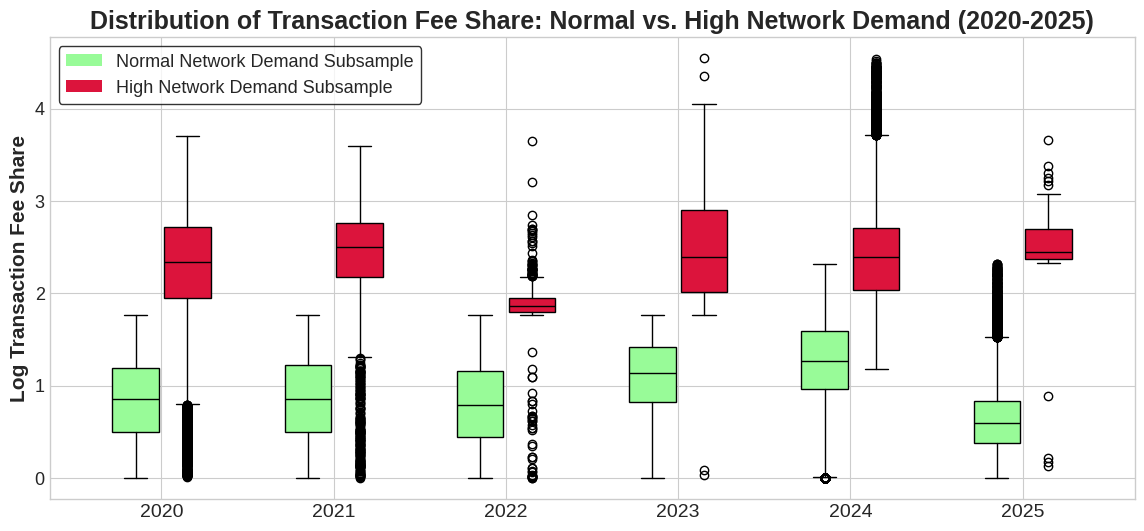

In [ ]:
from matplotlib.patches import Patch

years = sorted(normal_demandRead['year'].unique())

normal_data = [
    normal_demandRead.loc[normal_demandRead['year'] == y, 'fee_share_log'].dropna()
    for y in years
]

high_data = [
    high_demand.loc[high_demand['year'] == y, 'fee_share_log'].dropna()
    for y in years
]

plt.figure(figsize=(14, 6))

pos = np.arange(len(years))
width = 0.3

plt.boxplot(
    normal_data,
    positions=pos - width/2,
    widths=0.27,
    patch_artist=True,
    boxprops=dict(facecolor='palegreen'),
    medianprops=dict(color='black')
)

plt.boxplot(
    high_data,
    positions=pos + width/2,
    widths=0.27,
    patch_artist=True,
    boxprops=dict(facecolor='crimson'),
    medianprops=dict(color='black')
)

plt.xticks(pos, years)

legend_elements = [
    Patch(facecolor='palegreen', edgecolor='none', label='Normal Network Demand Subsample'),
    Patch(facecolor='crimson', edgecolor='none', label='High Network Demand Subsample')
]

plt.legend(handles=legend_elements, fontsize=13, loc='upper left', frameon=True, facecolor='white', edgecolor='black')

plt.title('Distribution of Transaction Fee Share: Normal vs. High Network Demand (2020-2025)', fontsize=18, fontweight='bold')
plt.ylabel('Log Transaction Fee Share', fontsize=15, fontweight='bold')
plt.tick_params('y', labelsize=13)
plt.tick_params('x', labelsize=14)

plt.show()

In [ ]:
print(round(high_demand[high_demand['year'] == 2020]['fee_share_log'].describe(), 3))
print(round(high_demand[high_demand['year'] == 2021]['fee_share_log'].describe(), 3))
print(round(high_demand[high_demand['year'] == 2022]['fee_share_log'].describe(), 3))
print(round(high_demand[high_demand['year'] == 2023]['fee_share_log'].describe(), 3))
print(round(high_demand[high_demand['year'] == 2024]['fee_share_log'].describe(), 3))
print(round(high_demand[high_demand['year'] == 2025]['fee_share_log'].describe(), 3))

count    27799.000
mean         2.299
std          0.572
min          0.014
25%          1.948
50%          2.339
75%          2.715
max          3.700
Name: fee_share_log, dtype: float64
count    21117.000
mean         2.464
std          0.424
min          0.005
25%          2.176
50%          2.499
75%          2.762
max          3.598
Name: fee_share_log, dtype: float64
count    1377.000
mean        1.865
std         0.286
min         0.002
25%         1.803
50%         1.864
75%         1.954
max         3.648
Name: fee_share_log, dtype: float64
count    17002.000
mean         2.496
std          0.552
min          0.029
25%          2.015
50%          2.392
75%          2.899
max          4.545
Name: fee_share_log, dtype: float64
count    12551.000
mean         2.461
std          0.538
min          1.184
25%          2.035
50%          2.391
75%          2.706
max          4.536
Name: fee_share_log, dtype: float64
count    66.000
mean      2.459
std       0.617
min       0.129
25% 

In [ ]:
normal_demandRead = normal_demand.copy()

normal_demandRead.set_index('time', drop=True, inplace=True)
normal_demandRead.drop(columns=normal_demandRead.select_dtypes(include='object').columns, inplace=True)
normal_demandRead = normal_demandRead.resample('ME').median()
normal_demandRead.head()

,id,block_time_secs,median_time,size,stripped_size,weight,version,version_bits,nonce,bits,...,generation,generation_usd,reward,reward_usd,bitcoin_price_usd,fee_share,fee_share_log,block_subsidy_share,block_subsidy_share_log,high_net_demand
time,,,,,,,,,,,,,,,,,,,,,
2020-01-31,613102.5,361.0,2020-01-16 14:02:30,1177429.0,864950.0,3993014.0,541065216.0,1.000000e+29,1.775463e+09,387124344.0,...,1.250000e+09,104779.6250,1.259859e+09,105535.17575,8358.98,0.782559,0.578050,99.217441,4.607342,0.0
2020-02-29,617572.5,369.5,2020-02-16 01:23:30,1221919.5,885567.0,3993218.0,541065216.0,1.000000e+29,1.862377e+09,387067068.0,...,1.250000e+09,120739.2422,1.263868e+09,122280.55860,9674.30,1.097274,0.740638,98.902726,4.604197,0.0
2020-03-31,620937.0,315.0,2020-03-09 11:23:00,1197764.0,882622.0,3993156.0,541065216.0,1.000000e+29,1.823656e+09,387067068.0,...,1.250000e+09,101579.1250,1.263255e+09,102644.79690,8002.88,1.049264,0.717481,98.950736,4.604677,0.0
2020-04-30,625920.0,350.0,2020-04-14 08:20:00,1205282.0,892228.0,3993198.0,541065216.0,1.000000e+29,1.814468e+09,387129532.0,...,1.250000e+09,86346.6250,1.261476e+09,87654.26560,7021.64,0.909738,0.646966,99.090262,4.606072,0.0
2020-05-31,629889.5,145.5,2020-05-11 02:21:00,1210114.0,918683.5,3993322.5,542109696.0,1.000000e+29,1.797120e+09,387031859.0,...,1.250000e+09,109407.7500,1.254432e+09,110679.90625,8988.01,1.730173,1.004365,98.269827,4.597842,0.0


In [ ]:
high_demandRead = high_demand.copy()

high_demandRead.set_index('time', drop=True, inplace=True)
high_demandRead.drop(columns=high_demandRead.select_dtypes(include='object').columns, inplace=True)
high_demandRead = high_demandRead.resample('ME').median()
high_demandRead.head()

,id,block_time_secs,median_time,size,stripped_size,weight,version,version_bits,nonce,bits,...,generation_usd,reward,reward_usd,bitcoin_price_usd,fee_share,fee_share_log,block_subsidy_share,block_subsidy_share_log,high_net_demand,year
time,,,,,,,,,,,,,,,,,,,,,
2020-01-31,612357.0,1390.0,2020-01-11 12:31:00,1272610.0,903205.0,3993340.0,541065216.0,1.000000e+29,1.807021e+09,387212786.0,...,103507.1250,1.287179e+09,106623.48440,8338.910,2.888407,1.358000,97.111593,4.586106,1.0,2020.0
2020-02-29,617363.5,1330.0,2020-02-14 11:55:00,1308416.5,893226.5,3993333.0,541065216.0,1.000000e+29,1.945585e+09,387062484.0,...,123618.1250,1.286937e+09,127878.00780,9862.720,2.870137,1.353290,97.129863,4.586292,1.0,2020.0
2020-03-31,622223.5,745.0,2020-03-19 19:33:30,1279978.0,895035.5,3993307.5,541065216.0,1.000000e+29,1.863052e+09,386990361.0,...,77106.7500,1.303791e+09,79286.71095,6161.995,4.125717,1.634270,95.874283,4.573414,1.0,2020.0
2020-04-30,627445.5,1113.0,2020-04-24 13:33:30,1285719.5,902249.0,3993341.5,541065216.0,1.000000e+29,1.858272e+09,387031859.0,...,92406.1250,1.290829e+09,95345.23435,7529.550,3.163007,1.426237,96.836993,4.583303,1.0,2020.0
2020-05-31,630529.5,587.0,2020-05-15 23:42:30,1293927.5,896533.0,3993346.0,541065216.0,1.000000e+29,1.805574e+09,387031859.0,...,60031.8125,7.766765e+08,73567.19145,9247.840,9.149634,2.317438,90.850366,4.520161,1.0,2020.0


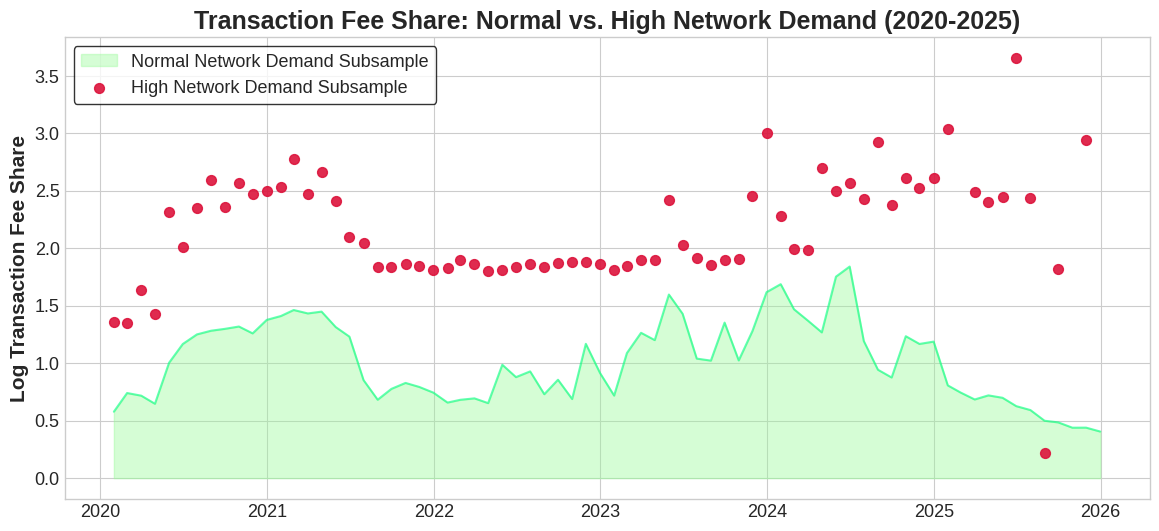

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(14,6))
col = ['#20C0B0']

plt.plot(normal_demandRead.index, normal_demandRead['fee_share_log'], color='springgreen', alpha=0.6)

plt.fill_between(
    normal_demandRead.index,
    normal_demandRead['fee_share_log'],
    color='palegreen',
    alpha=0.4,
    label='Normal Network Demand Subsample'
)

plt.scatter(high_demandRead.index, high_demandRead['fee_share_log'],
            color='crimson', s=50, zorder=3, alpha=0.9, label='High Network Demand Subsample')

plt.title('Transaction Fee Share: Normal vs. High Network Demand (2020-2025)', fontsize=18, fontweight='bold')
plt.ylabel('Log Transaction Fee Share', fontsize=15, fontweight='bold')
plt.tick_params('x', labelsize=13)
plt.tick_params('y', labelsize=13)
plt.legend(
    loc='upper left',
    fontsize=13,
    frameon=True,
    facecolor='white',
    edgecolor='black'
)

plt.show()

## Fee Reliance Increases

### Linear Model

In [ ]:
d.head()

,id,hash,time,block_time_secs,median_time,size,stripped_size,weight,version,version_hex,...,generation_usd,reward,reward_usd,guessed_miner,bitcoin_price_usd,fee_share,fee_share_log,block_subsidy_share,block_subsidy_share_log,high_net_demand
0,610691,00000000000000000001cc49c6ebb2e7546615e1f16816...,2020-01-01 00:03:00,NaN,2019-12-31 23:07:00,1250129,914500,3993629,549453824,20c00000,...,89939.375,1267534026,91200.9766,Unknown,7130.40,1.383318,0.868494,98.616682,4.601330,0
1,610692,000000000000000000117f1821db8f36e05a70ed9dbffa...,2020-01-01 00:07:00,267.0,2019-12-31 23:13:00,661706,424345,1934741,536870912,20000000,...,89939.375,1255524017,90336.8359,Unknown,7130.42,0.439977,0.364627,99.560023,4.610755,0
2,610693,00000000000000000014a2d6530192263dffbb1723acc9...,2020-01-01 00:13:00,362.0,2019-12-31 23:22:00,436344,284543,1289973,1073733632,3fffe000,...,89939.375,1254319091,90250.1406,F2Pool,7133.45,0.344338,0.295901,99.655662,4.611705,0
3,610694,000000000000000000053ba498a77d2e186a0d530abe5c...,2020-01-01 00:19:00,326.0,2019-12-31 23:37:00,467181,285676,1324209,1073733632,3fffe000,...,89939.375,1252776912,90139.1797,Unknown,7142.20,0.221661,0.200211,99.778339,4.612923,0
4,610695,00000000000000000009ae968a937bea55223270e64058...,2020-01-01 00:37:00,1112.0,2019-12-31 23:41:00,1123752,758667,3399753,545259520,20800000,...,89939.375,1258768740,90570.2969,AntPool,7148.87,0.696612,0.528634,99.303388,4.608199,0


In [ ]:
d['high_net_demand'].value_counts()

,count
high_net_demand,
0,239736
1,79912


In [ ]:
import statsmodels.api as sm

d = d.sort_values('time')
d['t'] = np.arange(len(d))

X = d[['t', 'high_net_demand']]
X = sm.add_constant(X)
y = d['fee_share_log']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          fee_share_log   R-squared:                       0.634
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                 2.774e+05
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        07:54:42   Log-Likelihood:            -2.2605e+05
No. Observations:              319648   AIC:                         4.521e+05
Df Residuals:                  319645   BIC:                         4.521e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.8828      0.002    4

In [ ]:
# Adjusting for autocollinearity and multicollinearity

d['t_scaled'] = (d['t'] - d['t'].mean()) / d['t'].std()

X = sm.add_constant(d[['t_scaled', 'high_net_demand']])
y = d['fee_share_log']

model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 10})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          fee_share_log   R-squared:                       0.634
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                 3.587e+04
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        07:54:48   Log-Likelihood:            -2.2605e+05
No. Observations:              319648   AIC:                         4.521e+05
Df Residuals:                  319645   BIC:                         4.521e+05
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.9070      0.002    3

### Visualization

In [ ]:
dRead = d.copy()
dRead.head()

,id,hash,time,block_time_secs,median_time,size,stripped_size,weight,version,version_hex,...,generation_usd,reward,reward_usd,guessed_miner,bitcoin_price_usd,fee_share,fee_share_log,block_subsidy_share,block_subsidy_share_log,high_net_demand
0,610691,00000000000000000001cc49c6ebb2e7546615e1f16816...,2020-01-01 00:03:00,NaN,2019-12-31 23:07:00,1250129,914500,3993629,549453824,20c00000,...,89939.375,1267534026,91200.9766,Unknown,7130.40,1.383318,0.868494,98.616682,4.601330,0
1,610692,000000000000000000117f1821db8f36e05a70ed9dbffa...,2020-01-01 00:07:00,267.0,2019-12-31 23:13:00,661706,424345,1934741,536870912,20000000,...,89939.375,1255524017,90336.8359,Unknown,7130.42,0.439977,0.364627,99.560023,4.610755,0
2,610693,00000000000000000014a2d6530192263dffbb1723acc9...,2020-01-01 00:13:00,362.0,2019-12-31 23:22:00,436344,284543,1289973,1073733632,3fffe000,...,89939.375,1254319091,90250.1406,F2Pool,7133.45,0.344338,0.295901,99.655662,4.611705,0
3,610694,000000000000000000053ba498a77d2e186a0d530abe5c...,2020-01-01 00:19:00,326.0,2019-12-31 23:37:00,467181,285676,1324209,1073733632,3fffe000,...,89939.375,1252776912,90139.1797,Unknown,7142.20,0.221661,0.200211,99.778339,4.612923,0
4,610695,00000000000000000009ae968a937bea55223270e64058...,2020-01-01 00:37:00,1112.0,2019-12-31 23:41:00,1123752,758667,3399753,545259520,20800000,...,89939.375,1258768740,90570.2969,AntPool,7148.87,0.696612,0.528634,99.303388,4.608199,0


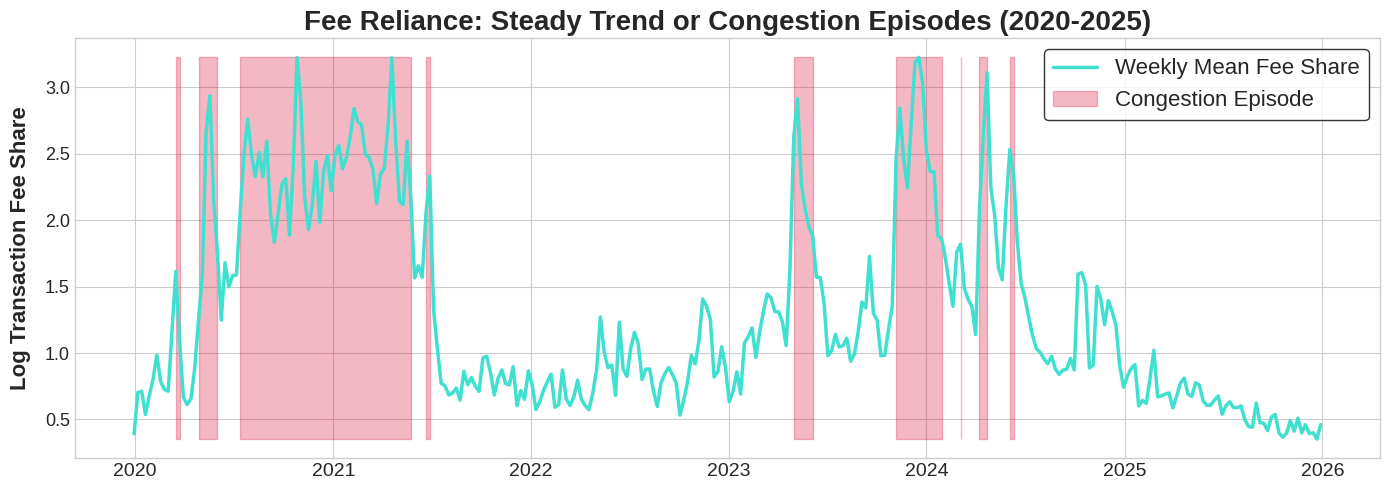

In [ ]:
dRead['week'] = pd.to_datetime(dRead.index.to_period('W').to_timestamp())

weekly = dRead.groupby('week').agg(
    fee_share_log=('fee_share_log', 'mean'),
    high_net_demand=('high_net_demand', lambda x: 1 if x.mean() > 0.5 else 0)
).reset_index()
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(weekly['week'], weekly['fee_share_log'],
        color='turquoise', lw=2.5, label='Weekly Mean Fee Share')
ax.fill_between(weekly['week'],
                weekly['fee_share_log'].min(),
                weekly['fee_share_log'].max(),
                where=weekly['high_net_demand'] == 1,
                alpha=0.3, color='crimson', label='Congestion Episode')

ax.set_ylabel('Log Transaction Fee Share', fontsize=16, fontweight='bold', labelpad=10)
ax.set_title('Fee Reliance: Steady Trend or Congestion Episodes (2020-2025)', fontsize=20, fontweight='bold')
plt.tick_params('x', labelsize=14)
plt.tick_params('y', labelsize=13)

plt.legend(
    loc='upper right',
    fontsize=16,
    frameon=True,
    facecolor='white',
    edgecolor='black'
)


plt.tight_layout()

## Volatility Comparison

In [ ]:
dRead = d.copy()
dRead.head()

,id,hash,time,block_time_secs,median_time,size,stripped_size,weight,version,version_hex,...,generation_usd,reward,reward_usd,guessed_miner,bitcoin_price_usd,fee_share,fee_share_log,block_subsidy_share,block_subsidy_share_log,high_net_demand
0,610691,00000000000000000001cc49c6ebb2e7546615e1f16816...,2020-01-01 00:03:00,NaN,2019-12-31 23:07:00,1250129,914500,3993629,549453824,20c00000,...,89939.375,1267534026,91200.9766,Unknown,7130.40,1.383318,0.868494,98.616682,4.601330,0
1,610692,000000000000000000117f1821db8f36e05a70ed9dbffa...,2020-01-01 00:07:00,267.0,2019-12-31 23:13:00,661706,424345,1934741,536870912,20000000,...,89939.375,1255524017,90336.8359,Unknown,7130.42,0.439977,0.364627,99.560023,4.610755,0
2,610693,00000000000000000014a2d6530192263dffbb1723acc9...,2020-01-01 00:13:00,362.0,2019-12-31 23:22:00,436344,284543,1289973,1073733632,3fffe000,...,89939.375,1254319091,90250.1406,F2Pool,7133.45,0.344338,0.295901,99.655662,4.611705,0
3,610694,000000000000000000053ba498a77d2e186a0d530abe5c...,2020-01-01 00:19:00,326.0,2019-12-31 23:37:00,467181,285676,1324209,1073733632,3fffe000,...,89939.375,1252776912,90139.1797,Unknown,7142.20,0.221661,0.200211,99.778339,4.612923,0
4,610695,00000000000000000009ae968a937bea55223270e64058...,2020-01-01 00:37:00,1112.0,2019-12-31 23:41:00,1123752,758667,3399753,545259520,20800000,...,89939.375,1258768740,90570.2969,AntPool,7148.87,0.696612,0.528634,99.303388,4.608199,0


In [ ]:
dRead.set_index('time', inplace=True, drop=True)
dRead = dRead.drop(columns=dRead.select_dtypes(include='object').columns)
dRead = dRead.resample('W').mean()
dRead.head()

,id,block_time_secs,median_time,size,stripped_size,weight,version,version_bits,nonce,bits,...,generation,generation_usd,reward,reward_usd,bitcoin_price_usd,fee_share,fee_share_log,block_subsidy_share,block_subsidy_share_log,high_net_demand
time,,,,,,,,,,,,,,,,,,,,,
2020-01-05,611098.0,530.017199,2020-01-03 11:45:38.208589056,8.233701e+05,567429.333742,2.525658e+06,6.956185e+08,1.027668e+29,2.036715e+09,3.872297e+08,...,1.250000e+09,90099.293558,1.257895e+09,90667.107334,7239.465693,0.624053,0.434694,99.375947,4.608905,0.013497
2020-01-12,612042.0,563.917055,2020-01-09 11:58:41.379310336,9.909434e+05,701773.895620,3.096265e+06,7.014082e+08,1.030527e+29,1.854047e+09,3.872128e+08,...,1.250000e+09,98953.189189,1.266044e+09,100224.416816,7939.423569,1.255753,0.721595,98.744247,4.602553,0.120224
2020-01-19,613098.0,581.761309,2020-01-16 11:06:01.501443584,1.006509e+06,712098.153032,3.142803e+06,6.829308e+08,1.026798e+29,1.934207e+09,3.871486e+08,...,1.250000e+09,107902.868585,1.265172e+09,109211.436004,8657.137526,1.187125,0.703469,98.812875,4.603239,0.062560
2020-01-26,614157.0,560.829472,2020-01-23 11:14:41.872103936,9.723369e+05,678155.035218,3.006802e+06,6.945782e+08,1.028548e+29,1.873298e+09,3.871243e+08,...,1.250000e+09,106904.205337,1.261033e+09,107851.114849,8503.207563,0.869205,0.562038,99.130795,4.606449,0.034291
2020-02-02,615209.0,589.669268,2020-01-30 11:59:15.921951232,1.048846e+06,727937.014634,3.232657e+06,6.790613e+08,1.026067e+29,1.902427e+09,3.870786e+08,...,1.250000e+09,115013.380482,1.263640e+09,116265.788726,9209.183971,1.072978,0.665321,98.927022,4.604408,0.037073


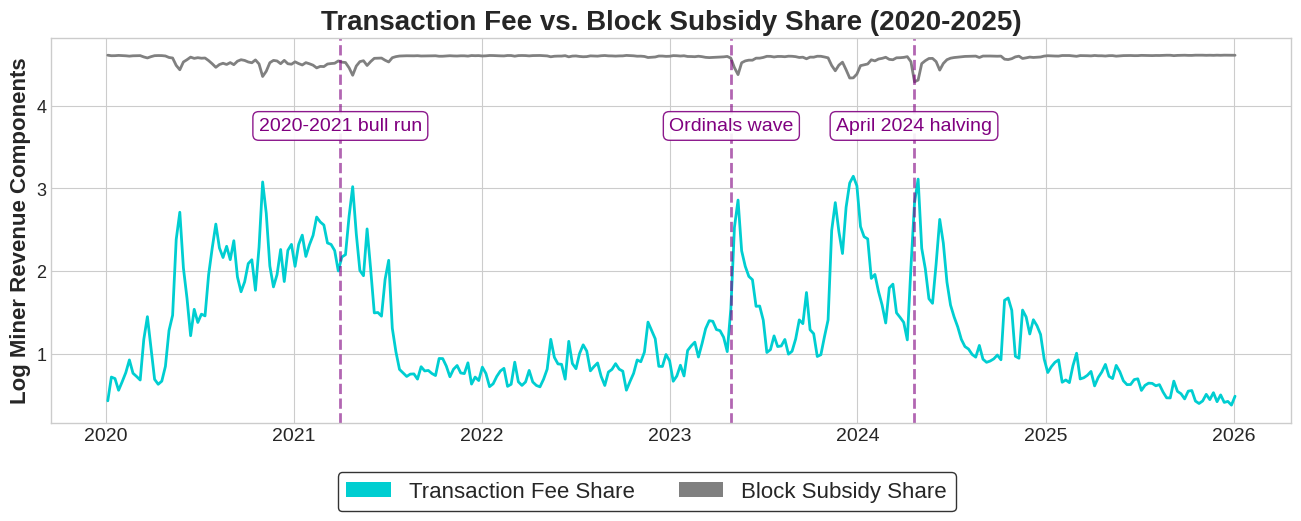

In [ ]:
from matplotlib.patches import Patch

plt.figure(figsize=(16,5))

plt.style.use('seaborn-v0_8-whitegrid')

plt.plot(dRead.index, dRead['fee_share_log'], color='darkturquoise', lw=2)
plt.plot(dRead.index, dRead['block_subsidy_share_log'], color='gray', lw=2)

ax = plt.gca()

events = {
    '2020-2021 bull run':    '2021-04-01',
    'Ordinals wave':   '2023-05-01',
    'April 2024 halving':  '2024-04-20',
}

for label, date in events.items():
    x = pd.Timestamp(date)

    ax.axvline(x, color='purple', linewidth=2, linestyle='--', alpha=0.6)

    ax.text(
        x,
        ax.get_ylim()[1] * 0.80,
        label,
        fontsize=14,
        color='purple',
        rotation=0,
        va='top',
        ha='center',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='white',
            edgecolor='purple',
            alpha=0.9
        )
    )

legend_elements = [
    Patch(facecolor='darkturquoise', edgecolor='none', label='Transaction Fee Share'),
    Patch(facecolor='gray', edgecolor='none', label='Block Subsidy Share')
]

plt.legend(
    handles=legend_elements,
    fontsize=16,
    loc='upper center',
    bbox_to_anchor=(0.48, -0.1),
    frameon=True,
    facecolor='white',
    edgecolor='black',
    ncol=2
)

plt.title('Transaction Fee vs. Block Subsidy Share (2020-2025)', fontsize=20, fontweight='bold')
plt.ylabel('Log Miner Revenue Components', fontsize=16, fontweight='bold')
plt.tick_params('y', labelsize=13)
plt.tick_params('x', labelsize=14)

plt.show()

In [ ]:
dRead = d.copy()
dRead.head()

,id,hash,time,block_time_secs,median_time,size,stripped_size,weight,version,version_hex,...,generation_usd,reward,reward_usd,guessed_miner,bitcoin_price_usd,fee_share,fee_share_log,block_subsidy_share,block_subsidy_share_log,high_net_demand
0,610691,00000000000000000001cc49c6ebb2e7546615e1f16816...,2020-01-01 00:03:00,NaN,2019-12-31 23:07:00,1250129,914500,3993629,549453824,20c00000,...,89939.375,1267534026,91200.9766,Unknown,7130.40,1.383318,0.868494,98.616682,4.601330,0
1,610692,000000000000000000117f1821db8f36e05a70ed9dbffa...,2020-01-01 00:07:00,267.0,2019-12-31 23:13:00,661706,424345,1934741,536870912,20000000,...,89939.375,1255524017,90336.8359,Unknown,7130.42,0.439977,0.364627,99.560023,4.610755,0
2,610693,00000000000000000014a2d6530192263dffbb1723acc9...,2020-01-01 00:13:00,362.0,2019-12-31 23:22:00,436344,284543,1289973,1073733632,3fffe000,...,89939.375,1254319091,90250.1406,F2Pool,7133.45,0.344338,0.295901,99.655662,4.611705,0
3,610694,000000000000000000053ba498a77d2e186a0d530abe5c...,2020-01-01 00:19:00,326.0,2019-12-31 23:37:00,467181,285676,1324209,1073733632,3fffe000,...,89939.375,1252776912,90139.1797,Unknown,7142.20,0.221661,0.200211,99.778339,4.612923,0
4,610695,00000000000000000009ae968a937bea55223270e64058...,2020-01-01 00:37:00,1112.0,2019-12-31 23:41:00,1123752,758667,3399753,545259520,20800000,...,89939.375,1258768740,90570.2969,AntPool,7148.87,0.696612,0.528634,99.303388,4.608199,0


In [ ]:
dRead['year'] = dRead['time'].dt.year


print(round(dRead[dRead['year'] == 2020]['fee_share_log'].describe(), 3))
print(round(dRead[dRead['year'] == 2021]['fee_share_log'].describe(), 3))
print(round(dRead[dRead['year'] == 2022]['fee_share_log'].describe(), 3))
print(round(dRead[dRead['year'] == 2023]['fee_share_log'].describe(), 3))
print(round(dRead[dRead['year'] == 2024]['fee_share_log'].describe(), 3))
print(round(dRead[dRead['year'] == 2025]['fee_share_log'].describe(), 3))

count    53222.000
mean         1.613
std          0.887
min          0.000
25%          0.864
50%          1.610
75%          2.372
max          3.700
Name: fee_share_log, dtype: float64
count    52686.000
mean         1.507
std          0.900
min          0.000
25%          0.741
50%          1.361
75%          2.358
max          3.598
Name: fee_share_log, dtype: float64
count    53188.000
mean         0.831
std          0.471
min          0.000
25%          0.450
50%          0.808
75%          1.184
max          3.648
Name: fee_share_log, dtype: float64
count    53999.000
mean         1.542
std          0.788
min          0.000
25%          0.980
50%          1.397
75%          1.964
max          4.545
Name: fee_share_log, dtype: float64
count    53471.000
mean         1.566
std          0.677
min          0.000
25%          1.056
50%          1.463
75%          1.965
max          4.536
Name: fee_share_log, dtype: float64
count    53082.000
mean         0.633
std          0.350
min

In [ ]:
print(round(dRead[dRead['year'] == 2020]['block_subsidy_share_log'].describe(), 3))
print(round(dRead[dRead['year'] == 2021]['block_subsidy_share_log'].describe(), 3))
print(round(dRead[dRead['year'] == 2022]['block_subsidy_share_log'].describe(), 3))
print(round(dRead[dRead['year'] == 2023]['block_subsidy_share_log'].describe(), 3))
print(round(dRead[dRead['year'] == 2024]['block_subsidy_share_log'].describe(), 3))
print(round(dRead[dRead['year'] == 2025]['block_subsidy_share_log'].describe(), 3))

count    53222.000
mean         4.548
std          0.071
min          4.120
25%          4.514
50%          4.575
75%          4.601
max          4.615
Name: block_subsidy_share_log, dtype: float64
count    52686.000
mean         4.555
std          0.066
min          4.182
25%          4.516
50%          4.586
75%          4.604
max          4.615
Name: block_subsidy_share_log, dtype: float64
count    53188.000
mean         4.599
std          0.013
min          4.153
25%          4.592
50%          4.603
75%          4.609
max          4.615
Name: block_subsidy_share_log, dtype: float64
count    53999.000
mean         4.553
std          0.088
min          2.058
25%          4.553
50%          4.585
75%          4.599
max          4.615
Name: block_subsidy_share_log, dtype: float64
count    53471.000
mean         4.557
std          0.102
min          2.160
25%          4.552
50%          4.582
75%          4.596
max          4.615
Name: block_subsidy_share_log, dtype: float64
count    5